In [1]:
#import packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
import cartopy.crs as ccrs
import time
import matplotlib as mpl
from scipy.stats import linregress
import dask
import matplotlib.ticker as mticker
import string
letters=[]
for letter in string.ascii_lowercase[0:24]:
    letters.append(letter+". ")

In [2]:
from functions import *
era_land=xr.open_dataset('eralandmask_regid.nc').rename({'lat':'latitude','lon':'longitude'})

## Climatology plots

In [3]:
#models
###'HadGEM3-GC31-MM'
models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models=models1+models22#['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR', 'CanESM5','CESM2', 'CESM2-WACCM','CMCC-ESM2', 'CMCC-CM2-SR5','CNRM-ESM2-1', 'CNRM-CM6-1', 'CNRM-CM6-1-HR','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR','KIOST-ESM','MIROC6', 'MIROC-ES2L','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']
len(models)

25

In [6]:
#concatenate models

# heat_mult.to_netcdf('cmip6/heat/cmip6_hot_25mods_1950-2021.nc')
#heat_mult=xr.open_dataset('cmip6/heat/cmip6_hot_25mods_1950-2021.nc')
htfut_dtcmip2=[]
for i,mod in enumerate(models):
    trseas_heatfut2=xr.open_dataset('cmip6/heat/'+mod+'_tasmean_detrended_heat_days_1950-2100_fixednew.nc').heatdays
    htfut_midl2=cutmidlat(trseas_heatfut2)
    #htfut_lnd2=landmask(htfut_midl2)

    htfut_lnd2=landmask(htfut_midl2)#.sel(time=slice('1950-01-01','2099-12-31'))
    heat_midlat=htfut_lnd2.drop_duplicates(dim="time").sel(time=slice('1950-01-01','2021-12-31'))

#     if i==9:
#         heat_midlat2=xr.concat([heat_midlat,htfut_cmip2[0].sel(time='2026-01-01')], dim='time')
#         heat_midlat2[-1,]=heat_midlat.sel(time='2026-01-02').isel(time=0).values
#         heat_midlat=heat_midlat2.sortby(heat_midlat2.time) 
    if i>0:
        heat_midlat['time']= htfut_dtcmip2[0].time.values
    htfut_dtcmip2.append(heat_midlat)

detheat_mult=xr.concat(htfut_dtcmip2,dim='models')
detheat_mult21=detheat_mult.sel(time=slice('1950-01-01','2021-12-31'))

In [8]:
#read ERA5 and berkley

detheatera=xr.open_dataset('era5/era5_detrended_tasmean_heat_days_1950-2024_fixednew.nc')
detheat1era=detheatera.sortby(detheatera.time)
#heat79=cuttimestart(heat1,1979)
detheat_midlera=cutmidlat(detheat1era)


detheat_midlatera=landmask(detheat_midlera)
detheat_midlat21era=detheat_midlatera.sel(time=slice('1950-01-01','2021-12-31'))


detheat_bk=xr.open_dataset('berkeley/berkeley_detrended_tasmean_heat_days_1950-2024_fixednew.nc')
detheat1_bk=detheat_bk.sortby(detheat_bk.time)
#heat79=cuttimestart(heat1,1979)
detheatbk_midl=cutmidlat(detheat1_bk)

detheatbk_midlat=landmask(detheatbk_midl)

In [11]:
#seasonal average
#detheat_mult21=detheat_mult21.to_dataset(name='htdays')
detheat_seas_m=landmask(detheat_mult).groupby("time.year").map(
        lambda x: x.groupby("time.season").sum("time")
    )


detheatera_seas_m=landmask(detheat_midlat21era).heatdays.groupby("time.year").map(
        lambda x: x.groupby("time.season").sum("time")
    )

detheatbk_seas_m=landmask(detheatbk_midlat).heatdays.groupby("time.year").map(
        lambda x: x.groupby("time.season").sum("time")
    )


In [12]:
#hatching for CMIP CI

cmip_detseasmean_m=detheat_seas_m.mean(dim=['year'])

cmip_detseasmean_mmm=cmip_detseasmean_m.mean(dim=['models'])

cmip_detseasmean_upper1=cmip_detseasmean_m.quantile(0.975,dim=['models'])
cmip_detseasmean_lower1=cmip_detseasmean_m.quantile(0.025,dim=['models'])

# cmip_detseasmean_upper2=cmip_detseasmean_mmm+(1.96*cmip_detseasmean.std(dim='models'))
# cmip_detseasmean_lower2=cmip_detseasmean_mmm-(1.96*cmip_detseasmean.std(dim='models'))
detheatera_seas=detheatera_seas_m.mean(dim=['year'])
detheatbk_seas=detheatbk_seas_m.mean(dim=['year'])
era_hatch1=xr.where((detheatera_seas>cmip_detseasmean_upper1)|(detheatera_seas<cmip_detseasmean_lower1), 1,np.nan)
bk_hatch1=xr.where((detheatbk_seas>cmip_detseasmean_upper1)|(detheatbk_seas<cmip_detseasmean_lower1), 1,np.nan)


In [13]:
#landmask
detheat_seas=landmask(detheat_seas_m.mean(dim='year'))
detheatera_seas=landmask(detheatera_seas_m.mean(dim='year'))
detheatbk_seas=landmask(detheatbk_seas_m.mean(dim='year'))

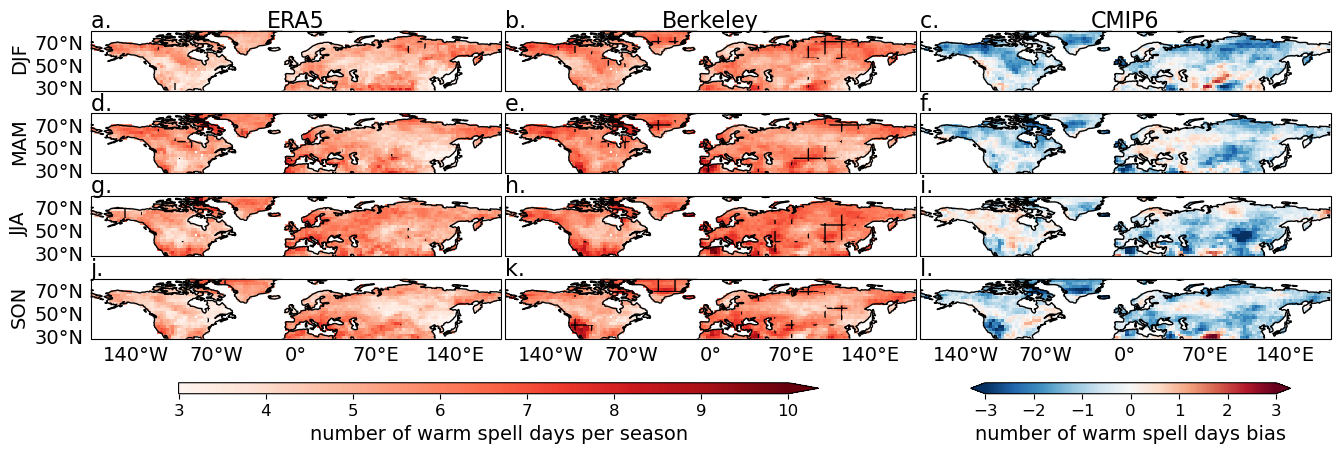

In [55]:
#plot
# dats1=[heat_seas.htdays.isel(season=0),heat_seas.htdays.isel(season=1),heat_seas.htdays.isel(season=2),heat_seas.htdays.isel(season=3)]
# dats2=[heatera_seas.t2m.isel(season=0),heatera_seas.t2m.isel(season=1),heatera_seas.t2m.isel(season=2),heatera_seas.t2m.isel(season=3)]
# dats3=[heatbk_seas.t2m.isel(season=0),heatbk_seas.t2m.isel(season=1),heatbk_seas.t2m.isel(season=2),heatbk_seas.t2m.isel(season=3)]

#dats2=[heat_seasonal_pvalues.pvalues.isel(season=0),heat_seasonal_pvalues.pvalues.isel(season=1),heat_seasonal_pvalues.pvalues.isel(season=2),heat_seasonal_pvalues.pvalues.isel(season=3)]

titles=detheatera_seas.season.values
#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(16,5.5))
numplots=np.arange(1,5)

order=np.array([0,2,1,3])
for i in range (4):
    ax=fig.add_subplot(4,3,3*numplots[i]-2,projection=ccrs.PlateCarree())
    m=detheatera_seas.isel(season=order[i]).plot(ax=ax,vmin=3,vmax=10,cmap='Reds',transform=ccrs.PlateCarree(),extend='max',add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

    ax.contourf(era_hatch1.longitude,era_hatch1.latitude, era_hatch1.isel(season=order[i]),hatches='++++' ,alpha=0)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.92)
    ax.text(-0.15, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)

    if i==0:
        ax.set_title('ERA5',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    
    if i<3:
        gl.bottom_labels = False
        
        
    ax=fig.add_subplot(4,3,3*numplots[i]-1,projection=ccrs.PlateCarree())
    m=detheatbk_seas.isel(season=order[i]).plot(ax=ax,vmin=3,vmax=10,cmap='Reds',transform=ccrs.PlateCarree(),extend='max',add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

    ax.contourf(bk_hatch1.longitude,bk_hatch1.latitude, bk_hatch1.isel(season=order[i]),hatches='++++' ,alpha=0)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    
    #ax.text(0.04, 0.96, letters[3*i+2], transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='left', fontsize=12, color='black')
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.92)
    
    if i==0:
        ax.set_title('Berkeley',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
#     if i%2>0:
#         gl.left_labels = False
    
    ax=fig.add_subplot(4,3,3*numplots[i],projection=ccrs.PlateCarree())
    m2=(detheat_seas.mean(dim='models').isel(season=order[i])- detheatbk_seas.isel(season=order[i])).plot(ax=ax,cmap='RdBu_r', vmax=3, vmin=-3,transform=ccrs.PlateCarree(),extend='max',add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

    

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i==0:
        ax.set_title('CMIP6',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.92)
   #     if titles.any():
#         ax.set_title('CMIP6 '+titles[i])
    if i<3:
        gl.bottom_labels = False
           
cbar_ax = fig.add_axes([0.18, 0.2, 0.4, 0.02])
cbl=fig.colorbar(m, cax=cbar_ax, extend='max',orientation='horizontal')

cbl.set_label(label="number of warm spell days per season",size=14)
cbl.ax.tick_params(labelsize=12)

cbar_ax = fig.add_axes([0.675, 0.2, 0.2, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')

cbl.set_label(label="number of warm spell days bias",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.01, wspace=0.01, bottom=0.28)



#plt.tight_layout()
plt.savefig('plots_fix/detrended_hotspell_climatology_supporting.png')
plt.show()

## warmspell trends

In [3]:
#read cmip trends
trseas_mn=xr.open_dataset('cmip6/heat/cmip6_hot_trend_25mods_1950-2021_fixednew.nc').htdays
pvseas_mn=xr.open_dataset('cmip6/heat/cmip6_hot_trendpvals_25mods_1950-2021_fixednew.nc').htdays

In [4]:
#read era5 trend
trseas_mn_era=xr.open_dataset('era5/era5_hot_trend_final_1950-2021_fixednew.nc').htdays
pvseas_mn_era=xr.open_dataset('era5/era5_hot_trendpvals_final_1950-2021_fixednew.nc').htdays

In [5]:
#read berkley trend
trseas_mn_bk= xr.open_dataset('berkeley/berkeley_hot_trend_final_1950-2021_fixednew.nc').htdays
pvseas_mn_bk= xr.open_dataset('berkeley/berkeley_hot_trendpvals_final_1950-2021_fixednew.nc').htdays

In [6]:
#hatching for CMIP CI
trseas_heat=landmask(trseas_mn).copy(deep=True)
trseasera_heat=landmask(trseas_mn_era).copy(deep=True)
trseasbk_heat=landmask(trseas_mn_bk).copy(deep=True)

cmip_seastr_upper1=trseas_heat.quantile(0.975,dim=['models'])
cmip_seastr_lower1=trseas_heat.quantile(0.025,dim=['models'])

era_hatch_tr=xr.where((trseasera_heat>cmip_seastr_upper1)|(trseasera_heat<cmip_seastr_lower1), 1,np.nan)
bk_hatch_tr=xr.where((trseasbk_heat>cmip_seastr_upper1)|(trseasbk_heat<cmip_seastr_lower1), 1,np.nan)



/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [7]:
#zonal vatiations

trend_dif_cmip_or=(10*trseas_heat).mean(dim='longitude')
trend_dif_cmip_mean_or=trend_dif_cmip_or.mean(dim='models')
trend_dif_cmip_upper_or=trend_dif_cmip_or.quantile(0.975,dim='models')
trend_dif_cmip_lower_or=trend_dif_cmip_or.quantile(0.025,dim='models')

trend_dif_era_or=(10*trseasera_heat).mean(dim='longitude')
trend_dif_bk_or=(10*trseasbk_heat).mean(dim='longitude')

In [ ]:
#plot
titles=trseas_heat.season.values
#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(18,6.5))
numplots=np.arange(1,5)
gs = fig.add_gridspec(5,4)

order=np.array([0,2,1,3])
for i in range (4):
    if i ==0:
        ax=fig.add_axes([0.1,0.75,0.3,0.15],projection=ccrs.PlateCarree())
    elif i ==1:
        ax=fig.add_axes([0.1,0.58,0.3,0.15],projection=ccrs.PlateCarree())
    elif i ==2:
        ax=fig.add_axes([0.1,0.41,0.3,0.15],projection=ccrs.PlateCarree())
    else:
        ax=fig.add_axes([0.1,0.24,0.3,0.15],projection=ccrs.PlateCarree())
        
     
    pvs=xr.where(pvseas_mn_bk.isel(season=order[i])<0.05,trseasbk_heat.isel(season=order[i]),np.nan) 
#     pval=xr.where(pvs>0.8,trseas_mn_era.isel(season=order[i]),np.nan) 
    m1=(10*pvs).plot(ax=ax, vmax=6,vmin=0,cmap='Reds',transform=ccrs.PlateCarree(),add_colorbar=False)

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    #gl.left_labels = False
    
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.96)
    ax.text(-0.12, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 
    ax.coastlines()
    if i==0:
        ax.set_title('Berkeley Earth trends', fontsize=16, y=0.96)
    else:
        ax.set_title('')
    
    if i<3:
        gl.bottom_labels = False
           
        
    if i ==0:
        ax=fig.add_axes([0.41,0.75,0.3,0.15],projection=ccrs.PlateCarree())
    elif i ==1:
        ax=fig.add_axes([0.41,0.58,0.3,0.15],projection=ccrs.PlateCarree())
    elif i ==2:
        ax=fig.add_axes([0.41,0.41,0.3,0.15],projection=ccrs.PlateCarree())
    else:
        ax=fig.add_axes([0.41,0.24,0.3,0.15],projection=ccrs.PlateCarree())

    difs=10*trseas_heat.isel(season=order[i]).mean(dim='models') - 10*trseasbk_heat.isel(season=order[i])

    m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(bk_hatch_tr.longitude,bk_hatch_tr.latitude, bk_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('CMIP6 biases', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    
    if i<3:
        gl.bottom_labels = False

    if i==0:
        ax=fig.add_axes([0.73,0.77,0.12,0.115])
    elif i==1:
        ax=fig.add_axes([0.73,0.6,0.12,0.115])

    elif i==2:
        ax=fig.add_axes([0.73,0.43,0.12,0.115])
        #ax.set_yticks([])
    else:
        ax=fig.add_axes([0.73,0.26,0.12,0.115])
        #ax.set_yticks([])
        
    lat=trend_dif_cmip_mean_or.latitude
    ax.plot(trend_dif_cmip_mean_or.isel(season=order[i]),lat,  color='blue', label='CMIP6')
    ax.plot(trend_dif_cmip_upper_or.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.plot(trend_dif_cmip_lower_or.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,trend_dif_cmip_lower_or.isel(season=order[i]), trend_dif_cmip_upper_or.isel(season=order[i]), color='lightblue', alpha=0.5)
    #ax.axvline(color='k', linestyle='--')
    ax.plot(trend_dif_bk_or.isel(season=order[i]),lat, color='black', label='Berkeley')
    ax.plot(trend_dif_era_or.isel(season=order[i]),lat,linestyle='--', color='black', label='ERA5')
    
    #ax.set_title(titles[i])
    ax.set_xlim([0,4])
    #ax.set_ylabel('Latitude',fontsize=12)
    ax.set_xticks(np.arange(0, 5, 1))
    ax.set_yticks([30,50,70])
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.96)
    if i==0:
        ax.set_title('Zonal mean', fontsize=16,y=0.96)
    else:
        ax.set_title('')
        
    if i<3:
        ax.set_xticks([])
    else:
        ax.set_xlabel("hot spell days trend per decade",fontsize=14)
    if i==3:
        plt.legend(loc='lower left', ncol=2, bbox_to_anchor=(-0.18, -1.7),columnspacing=0.5, fontsize=14)
    
#     if i==2 or i==3:

#         ax.set_ylabel(' ')
#     elif i==3:
#         plt.legend()
#     if i%2>0:
#         gl.left_labels = False
        
cbar_ax = fig.add_axes([0.125, 0.17, 0.25, 0.02])
cbl=fig.colorbar(m1, cax=cbar_ax, extend='max',orientation='horizontal')
cbl.set_label(label="hot spell days trend (days/season/decade)",size=14)
cbl.ax.tick_params(labelsize=12)

cbar_ax = fig.add_axes([0.43, 0.17, 0.25, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="hot spell days trend bias (days/season/decade)",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.03, wspace=0.01, bottom=0.28)

# plt.tight_layout()
plt.savefig('plots_fix/hotspell_trends_per_season_main.png')
plt.show()

In [8]:
#zonal vatiations seasonal deviation
trend_annual_mn2=trseas_heat.mean(dim='season')
trend_annual_mn2_era=trseasera_heat.mean(dim='season')
trend_annual_mn2_bk=trseasbk_heat.mean(dim='season')

trend_ann_cmip=trend_annual_mn2.mean(dim='longitude')*10
trend_dif_cmip=((trseas_heat-trend_annual_mn2).mean(dim='longitude'))*10
trend_dif_cmip_mean=trend_dif_cmip.mean(dim='models')
trend_dif_cmip_upper=trend_dif_cmip.quantile(0.975,dim='models')
trend_dif_cmip_lower=trend_dif_cmip.quantile(0.025,dim='models')

trend_ann_era= trend_annual_mn2_era.mean(dim='longitude')*10
trend_dif_era=((trseasera_heat - trend_annual_mn2_era).mean(dim='longitude'))*10
trend_ann_bk=trend_annual_mn2_bk.mean(dim='longitude')*10
trend_dif_bk=((trseasbk_heat - trend_annual_mn2_bk).mean(dim='longitude'))*10

In [60]:
#hatching for CMIP CI
trseas_mndev=trseas_heat-trseas_heat.mean(dim='season')
cmip_seastr_upper1=trseas_mndev.quantile(0.975,dim=['models'])
cmip_seastr_lower1=trseas_mndev.quantile(0.025,dim=['models'])


trseas_mn_eradev=trseasera_heat-trseasera_heat.mean(dim='season')
trseas_mn_bkdev=trseasbk_heat-trseasbk_heat.mean(dim='season')

era_hatch_tr=xr.where((trseas_mn_eradev>cmip_seastr_upper1)|(trseas_mn_eradev<cmip_seastr_lower1), 1,np.nan)
bk_hatch_tr=xr.where((trseas_mn_bkdev>cmip_seastr_upper1)|(trseas_mn_bkdev<cmip_seastr_lower1), 1,np.nan)



/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


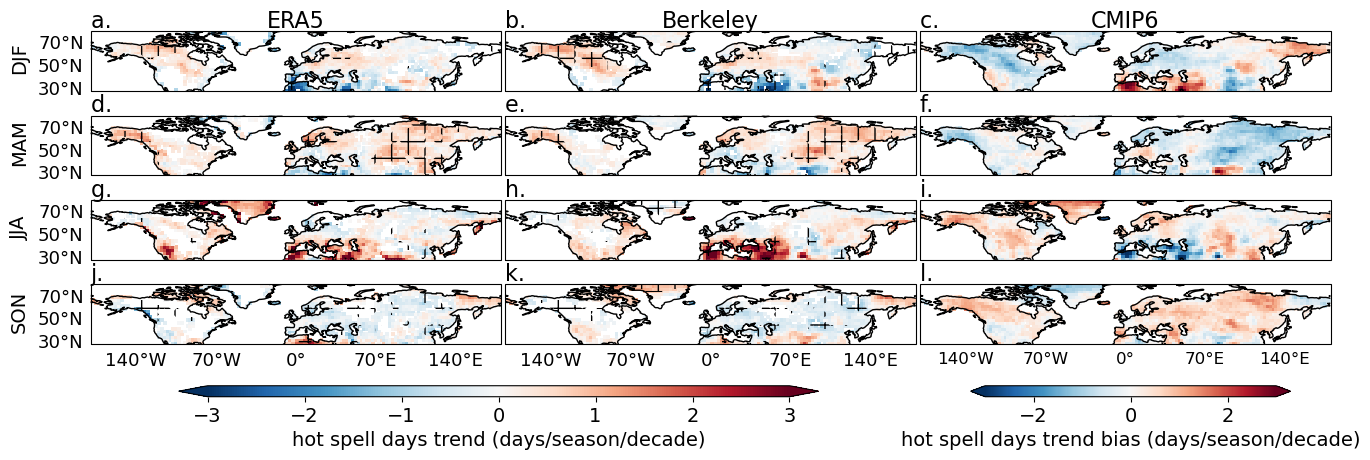

In [38]:
#plot
# dats1=[heat_seas.htdays.isel(season=0),heat_seas.htdays.isel(season=1),heat_seas.htdays.isel(season=2),heat_seas.htdays.isel(season=3)]
# dats2=[heatera_seas.t2m.isel(season=0),heatera_seas.t2m.isel(season=1),heatera_seas.t2m.isel(season=2),heatera_seas.t2m.isel(season=3)]
# dats3=[heatbk_seas.t2m.isel(season=0),heatbk_seas.t2m.isel(season=1),heatbk_seas.t2m.isel(season=2),heatbk_seas.t2m.isel(season=3)]

#dats2=[heat_seasonal_pvalues.pvalues.isel(season=0),heat_seasonal_pvalues.pvalues.isel(season=1),heat_seasonal_pvalues.pvalues.isel(season=2),heat_seasonal_pvalues.pvalues.isel(season=3)]

#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(16,5.5))
numplots=np.arange(1,5)

order=np.array([0,2,1,3])
for i in range (4):
    ax=fig.add_subplot(4,3,3*numplots[i]-2,projection=ccrs.PlateCarree())
    pvs=xr.where(pvseas_mn_era.isel(season=order[i])<0.05,trseas_mn_eradev.isel(season=order[i]),np.nan) 
#     pval=xr.where(pvs>0.8,trseas_mn_era.isel(season=order[i]),np.nan) 
    m1=(10*pvs).plot(ax=ax, vmax=3,vmin=-3,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

    ax.contourf(era_hatch_tr.longitude,era_hatch_tr.latitude, era_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.92)
    ax.text(-0.15, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)

    if i==0:
        ax.set_title('ERA5',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    
    if i<3:
        gl.bottom_labels = False
        
        
    ax=fig.add_subplot(4,3,3*numplots[i]-1,projection=ccrs.PlateCarree())
    pvs=xr.where(pvseas_mn_bk.isel(season=order[i])<0.05,trseas_mn_bkdev.isel(season=order[i]),np.nan) 
#     pval=xr.where(pvs>0.8,trseas_mn_era.isel(season=order[i]),np.nan) 
    m1=(10*pvs).plot(ax=ax, vmax=3,vmin=-3,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

    ax.contourf(bk_hatch_tr.longitude,bk_hatch_tr.latitude, bk_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    #ax.text(0.04, 0.96, letters[3*i+2], transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='left', fontsize=12, color='black')
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.92)
    
    if i==0:
        ax.set_title('Berkeley',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
#     if i%2>0:
#         gl.left_labels = False
    
    ax=fig.add_subplot(4,3,3*numplots[i],projection=ccrs.PlateCarree())
    difs=10*trseas_mndev.isel(season=order[i]).mean(dim='models') - 10*trseas_mn_bkdev.isel(season=order[i])
    m2=(difs).plot(ax=ax,cmap='RdBu_r', vmax=3, vmin=-3,transform=ccrs.PlateCarree(),extend='max',add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

    

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
    ax.coastlines()
    if i==0:
        ax.set_title('CMIP6',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.92)
   #     if titles.any():
#         ax.set_title('CMIP6 '+titles[i])
    if i<3:
        gl.bottom_labels = False
    
    
    
cbar_ax = fig.add_axes([0.18, 0.2, 0.4, 0.02])
cbl=fig.colorbar(m1, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="hot spell days trend (days/season/decade)",size=14)
cbl.ax.tick_params(labelsize=14)

cbar_ax = fig.add_axes([0.675, 0.2, 0.2, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="hot spell days trend bias (days/season/decade)",size=14)
cbl.ax.tick_params(labelsize=14)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.1, wspace=0.01, bottom=0.28)



# plt.tight_layout()
plt.savefig('plots_more/hotspell_devtrend_supporting.png')
plt.show()

## Temperature trend

In [9]:
#read cmip temp dat
temp_mult=xr.open_dataset('cmip6_tas_day_hist-ssp_25models_1950-2021_regridcon.nc')#.load()

In [10]:
#read cmip temp trend
trseas_mn=xr.open_dataset('cmip6_tas_day_hist_mktrends.nc').tas
pvseas_mn=xr.open_dataset('cmip6_tas_day_hist_mkpvals.nc').tas

trs_midl=cutmidlat(trseas_mn)
trseas_mn=landmask(trs_midl)

pvs_midl=cutmidlat(pvseas_mn)
pvseas_mn=landmask(pvs_midl)

In [11]:
#read ERA5 and berkley temp dats

tmn=xr.open_dataset('era5/era5_tmean_daily_1950_2024_regridcon.nc')
tmn1=tmn.sortby(tmn.time).rename({'lat':'latitude','lon':'longitude'})
#heat79=cuttimestart(heat1,1979)
tmn_midl=cutmidlat(rotlon_180(tmn1))

tmn_midlat=landmask(tmn_midl)
tmn_midlat21=tmn_midlat.sel(time=slice('1950-01-01','2021-12-31'))
tmn_noleap21=tmn_midlat21.convert_calendar('noleap')

tmn_bk=xr.open_dataset('berkley_tmean_1950-2021_regridcon.nc')
tmn_bk1=tmn_bk.sortby(tmn_bk.time).rename({'lat':'latitude','lon':'longitude'})
#heat79=cuttimestart(heat1,1979)
tmnbk_midl=cutmidlat(rotlon_180(tmn_bk1))

tmnbk_midlat=landmask(tmnbk_midl)
tmnbk_noleap=tmnbk_midlat.convert_calendar('noleap')
#



In [12]:
#read era5 trend
trseas_mn_era=xr.open_dataset('era5/era5_tmean_trend_final_1950-2021.nc').htdays
pvseas_mn_era=xr.open_dataset('era5/era5_tmean_trendpvals_final_1950-2021.nc').htdays


In [13]:
#read berkley trend
tmnbk_ch=tmnbk_midlat.chunk({'latitude': 26, 'longitude': 60})
tmnbk_seas=tmnbk_ch.groupby('time.season')

titles=tmnbk_seas.mean().season.values
# year= np.arange(1950,2025)

trseas_mn_bk=xr.open_dataset('berkeley/berkeley_tmean_trend_final_1950-2021.nc').htdays
pvseas_mn_bk=xr.open_dataset('berkeley/berkeley_tmean_trendpvals_final_1950-2021.nc').htdays

In [13]:
#hatching for CMIP CI

cmip_tmntr_upper1=trseas_mn.quantile(0.975,dim=['models'])
cmip_tmntr_lower1=trseas_mn.quantile(0.025,dim=['models'])

eratmn_hatch_tr=xr.where((trseas_mn_era>cmip_tmntr_upper1)|(trseas_mn_era<cmip_tmntr_lower1), 1,np.nan)
bktmn_hatch_tr=xr.where((trseas_mn_bk>cmip_tmntr_upper1)|(trseas_mn_bk<cmip_tmntr_lower1), 1,np.nan)



/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [14]:
#zonal variation
trseas_tmp=trseas_mn.copy(deep=True)
trseasera_tmp=trseas_mn_era.copy(deep=True)
trseasbk_tmp=trseas_mn_bk.copy(deep=True)

tmptrend_annual_mn2=trseas_tmp.mean(dim='season')
tmptrend_annual_mn2_era=trseas_mn_era.mean(dim='season')
tmptrend_annual_mn2_bk=trseas_mn_bk.mean(dim='season')

tmptrend_ann_cmip=tmptrend_annual_mn2.mean(dim='longitude')*10
tmptrend_dif_cmip=((trseas_tmp-tmptrend_annual_mn2).mean(dim='longitude'))*10
tmptrend_dif_cmip_mean=tmptrend_dif_cmip.mean(dim='models')
tmptrend_dif_cmip_upper=tmptrend_dif_cmip.quantile(0.975,dim='models')
tmptrend_dif_cmip_lower=tmptrend_dif_cmip.quantile(0.025,dim='models')

tmptrend_ann_era=tmptrend_annual_mn2_era.mean(dim='longitude')*10
tmptrend_dif_era=((trseas_mn_era - tmptrend_annual_mn2_era).mean(dim='longitude'))*10
tmptrend_ann_bk=tmptrend_annual_mn2_bk.mean(dim='longitude')*10
tmptrend_dif_bk=((trseas_mn_bk - tmptrend_annual_mn2_bk).mean(dim='longitude'))*10

### Median and lower quanile

In [37]:
#median slope
trseas_md= xr.open_dataset('cmip6_tas_day_median_hist_mktrends.nc').tas
pvseas_md=xr.open_dataset('cmip6_tas_day_median_hist_mkpvals.nc').tas
#era5 trend
trseas_md_era= xr.open_dataset('era5/era5_tmean_median_trend_final_1950-2021.nc').htdays
pvseas_md_era=xr.open_dataset('era5/era5_tmean_median_trendpvals_final_1950-2021.nc').htdays
#berkley
trseas_md_bk= xr.open_dataset('berkeley/berkeley_tmean_median_trend_final_1950-2021.nc').htdays
pvseas_md_bk=xr.open_dataset('berkeley/berkeley_tmean_median_trendpvals_final_1950-2021.nc').htdays

In [38]:
#latvar
# trseas_tmp=trseas_md.copy(deep=True)
# trseasera_tmp=trseas_md_era.copy(deep=True)
# trseasbk_tmp=trseas_md_bk.copy(deep=True)

tmptrend_annual_md2=trseas_md.mean(dim='season')
tmptrend_annual_md2_era=trseas_md_era.mean(dim='season')
tmptrend_annual_md2_bk=trseas_md_bk.mean(dim='season')

mdtrend_dif_cmip=((trseas_md-tmptrend_annual_md2).mean(dim='longitude'))*10
mdtrend_dif_cmip_mean=mdtrend_dif_cmip.mean(dim='models')
mdtrend_dif_cmip_upper=mdtrend_dif_cmip.quantile(0.975,dim='models')
mdtrend_dif_cmip_lower=mdtrend_dif_cmip.quantile(0.025,dim='models')
mdtrend_dif_era=((trseas_md_era - tmptrend_annual_md2_era).mean(dim='longitude'))*10
mdtrend_dif_bk=((trseas_md_bk - tmptrend_annual_md2_bk).mean(dim='longitude'))*10

#### 25th percentile

In [39]:
#q25 slope
trseas_q25= xr.open_dataset('cmip6_tas_day_q25_hist_mktrends.nc').tas
pvseas_q25=xr.open_dataset('cmip6_tas_day_q25_hist_mkpvals.nc').tas
#era5 trend
trseas_q25_era= xr.open_dataset('era5/era5_tmean_q25_trend_final_1950-2021.nc').htdays
pvseas_q25_era=xr.open_dataset('era5/era5_tmean_q25_trendpvals_final_1950-2021.nc').htdays
#berkley
trseas_q25_bk= xr.open_dataset('berkeley/berkeley_tmean_q25_trend_final_1950-2021.nc').htdays
pvseas_q25_bk=xr.open_dataset('berkeley/berkeley_tmean_q25_trendpvals_final_1950-2021.nc').htdays

In [54]:
#latvar
# trseas_tmp=trseas_q25.copy(deep=True)
# trseasera_tmp=trseas_q25_era.copy(deep=True)
# trseasbk_tmp=trseas_q25_bk.copy(deep=True)

tmptrend_annual_q252=trseas_q25.mean(dim='season')
tmptrend_annual_q252_era=trseas_q25_era.mean(dim='season')
tmptrend_annual_q252_bk=trseas_q25_bk.mean(dim='season')

q25trend_dif_cmip=((trseas_q25-tmptrend_annual_q252).mean(dim='longitude'))*10
q25trend_dif_cmip_mean=q25trend_dif_cmip.mean(dim='models')
q25trend_dif_cmip_upper=q25trend_dif_cmip.quantile(0.975,dim='models')
q25trend_dif_cmip_lower=q25trend_dif_cmip.quantile(0.025,dim='models')
q25trend_dif_era=((trseas_q25_era - tmptrend_annual_q252_era).mean(dim='longitude'))*10
q25trend_dif_bk=((trseas_q25_bk - tmptrend_annual_q252_bk).mean(dim='longitude'))*10

#### 75th percentile

In [41]:
#q75 slope
trseas_q75= xr.open_dataset('cmip6_tas_day_q75_hist_mktrends.nc').tas
pvseas_q75=xr.open_dataset('cmip6_tas_day_q75_hist_mkpvals.nc').tas
#era5 trend
trseas_q75_era= xr.open_dataset('era5/era5_tmean_q75_trend_final_1950-2021.nc').htdays
pvseas_q75_era=xr.open_dataset('era5/era5_tmean_q75_trendpvals_final_1950-2021.nc').htdays
#berkley
trseas_q75_bk= xr.open_dataset('berkeley/berkeley_tmean_q75_trend_final_1950-2021.nc').htdays
pvseas_q75_bk=xr.open_dataset('berkeley/berkeley_tmean_q75_trendpvals_final_1950-2021.nc').htdays

In [55]:
#latvar

tmptrend_annual_q752=trseas_q75.mean(dim='season')
tmptrend_annual_q752_era=trseas_q75_era.mean(dim='season')
tmptrend_annual_q752_bk=trseas_q75_bk.mean(dim='season')

q75trend_dif_cmip=((trseas_q75-tmptrend_annual_q752).mean(dim='longitude'))*10
q75trend_dif_cmip_mean=q75trend_dif_cmip.mean(dim='models')
q75trend_dif_cmip_upper=q75trend_dif_cmip.quantile(0.975,dim='models')
q75trend_dif_cmip_lower=q75trend_dif_cmip.quantile(0.025,dim='models')
q75trend_dif_era=((trseas_q75_era - tmptrend_annual_q752_era).mean(dim='longitude'))*10
q75trend_dif_bk=((trseas_q75_bk - tmptrend_annual_q752_bk).mean(dim='longitude'))*10

## Temp variability


In [15]:
#var seasonal mean 
temp_sdrolled=tmn_noleap21.rolling(time=10,center=True).std()
bktemp_sdrolled=tmnbk_noleap.rolling(time=10,center=True).std()
cmptemp_sdrolled=temp_mult.rolling(time=10,center=True).std()

temp_seas=temp_sdrolled.t2m.groupby('time.season').mean()
bktemp_seas=bktemp_sdrolled.temperature.groupby('time.season').mean()
cmptemp_seas=cmptemp_sdrolled.tas.groupby('time.season').mean()

In [16]:
#zonal variability
tmn_mult_var=temp_mult.tas.rolling(time=10).std()
var_annual_mn2=tmn_mult_var.groupby('time.season').mean().mean(dim='season')

tmn_era_var=tmn_noleap21.t2m.rolling(time=10).std()
var_annual_mn2_era=tmn_era_var.groupby('time.season').mean().mean(dim='season')

varseas_mn =tmn_mult_var.groupby('time.season').mean()
varseas_mn_era=tmn_era_var.groupby('time.season').mean()

var_dif_cmip=((varseas_mn-var_annual_mn2).mean(dim='longitude'))
var_dif_cmip_mean=var_dif_cmip.mean(dim='models')
var_dif_cmip_upper=var_dif_cmip.quantile(0.975,dim='models')
var_dif_cmip_lower=var_dif_cmip.quantile(0.025,dim='models')
var_dif_era=((varseas_mn_era - var_annual_mn2_era).mean(dim='longitude'))

tmn_bk_var=tmnbk_noleap.temperature.rolling(time=10).std()
var_annual_mn2_bk=tmn_bk_var.groupby('time.season').mean().mean(dim='season')
varseas_mn_bk=tmn_bk_var.groupby('time.season').mean()
var_dif_bk=((varseas_mn_bk - var_annual_mn2_bk).mean(dim='longitude'))

trseas_var=varseas_mn.copy(deep=True)
trseasera_var=varseas_mn_era.copy(deep=True)
trseasbk_var=varseas_mn_bk.copy(deep=True)

In [20]:
#hatching for CMIP CI

cmip_var_upper1=cmptemp_seas.quantile(0.975,dim=['models'])
cmip_var_lower1=cmptemp_seas.quantile(0.025,dim=['models'])

eravar_hatch_tr=xr.where((temp_seas>cmip_var_upper1)|(temp_seas<cmip_var_lower1), 1,np.nan)
bkvar_hatch_tr=xr.where((bktemp_seas>cmip_var_upper1)|(bktemp_seas<cmip_var_lower1), 1,np.nan)



/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [37]:
#variability trends

trvar_mn_cmp=xr.open_dataset('cmip6_tasvar_hist_mktrends.nc').tas
pvvar_mn_cmp=xr.open_dataset('cmip6_tasvar_hist_mkpvals.nc').tas

trvar_mn_era=xr.open_dataset('era5/era5_tmeanvar_trend_final_1950-2021.nc').htdays
pvvar_mn_era=xr.open_dataset('era5/era5_tmeanvar_trendpvals_final_1950-2021.nc').htdays

trvar_mn_bk=xr.open_dataset('berkeley/berkeley_tmeanvar_trend_final_1950-2021.nc').htdays
pvvar_mn_bk=xr.open_dataset('berkeley/berkeley_tmeanvar_trendpvals_final_1950-2021.nc').htdays

In [38]:
#hatching for CMIP CI

cmip_vartr_upper1=trvar_mn_cmp.quantile(0.975,dim=['models'])
cmip_vartr_lower1=trvar_mn_cmp.quantile(0.025,dim=['models'])

eravartr_hatch_tr=xr.where((trvar_mn_era>cmip_vartr_upper1)|(trvar_mn_bk<cmip_vartr_lower1), 1,np.nan)
bkvartr_hatch_tr=xr.where((trvar_mn_bk>cmip_vartr_upper1)|(trvar_mn_bk<cmip_vartr_lower1), 1,np.nan)



/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [ ]:
#var trend plot
# djf_slope=slope.compute()
# djf_pv=pval.compute()
#map_plotter2(trseas,pvseas,2,2,4,ssns,vmax=0.003,cmap='RdBu_r',height=5)
# dats=trseas*10
#dats2=

fig=plt.figure(figsize=(16,5.5))
numplots=np.arange(1,5)
for i in range (4):
    ax=fig.add_subplot(4,3,3*i+1,projection=ccrs.PlateCarree())
    
    pval=xr.where(pvvar_mn_era.isel(season=order[i])<0.05,trvar_mn_era.isel(season=order[i]),np.nan)
    m=(10*pval).plot(ax=ax,vmin=-0.15, vmax=0.15, cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})
    
      
    #ax.contourf(pval.longitude.values,pval.latitude.values,pval.values,hatches='.', alpha=0., transform=ccrs.PlateCarree())
    ax.contourf(eravartr_hatch_tr.longitude,eravartr_hatch_tr.latitude, eravartr_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
      
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    
    #gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
    ax.coastlines()
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.92)
    ax.text(-0.15, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)

    if i==0:
        ax.set_title('ERA5',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
        
    ax=fig.add_subplot(4,3,3*i+2,projection=ccrs.PlateCarree()) 
    pval=xr.where(pvvar_mn_bk.isel(season=order[i])<0.05,trvar_mn_bk.isel(season=order[i]),np.nan)
    m=(10*pval).plot(ax=ax,vmin=-0.15, vmax=0.15, cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})
    
      
    #ax.contourf(pval.longitude.values,pval.latitude.values,pval.values,hatches='.', alpha=0., transform=ccrs.PlateCarree())
      
    ax.contourf(bkvartr_hatch_tr.longitude,bkvartr_hatch_tr.latitude, bkvartr_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    #gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.92)
    if i==0:
        ax.set_title('Berkeley',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
        
    
    ax=fig.add_subplot(4,3,3*i+3,projection=ccrs.PlateCarree())
    
#     pvs1=xr.where(trvar_mn_cmp.isel(season=order[i])>0,1,0) 
#     pvs2=xr.where(trvar_mn_cmp.isel(season=order[i])<0,-1,0)
#     pval=xr.where((pvs1.mean(dim='models')>0.8)|(pvs2.mean(dim='models')<-0.8),trvar_mn_cmp.isel(season=order[i]).mean(dim='models'),np.nan) 

    m2=(10*trvar_mn_cmp.isel(season=order[i]).mean(dim='models') - trvar_mn_bk.isel(season=order[i])).plot(ax=ax,vmin=-0.1, vmax=0.1, cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})
    
      
    #ax.contourf(pval.longitude.values,pval.latitude.values,pval.values,hatches='.', alpha=0., transform=ccrs.PlateCarree())
      
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i==0:
        ax.set_title('CMIP6',fontsize=16, y=0.92)
    else:
        ax.set_title('')
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.92)
    
    if i<3:
        gl.bottom_labels = False
    
        
cbar_ax = fig.add_axes([0.18, 0.2, 0.4, 0.02])
cbl=fig.colorbar(m, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="10-day temperature variability trend",size=14)
cbl.ax.tick_params(labelsize=12)

cbar_ax = fig.add_axes([0.675, 0.2, 0.2, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="10-day temperature variability trend bias",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.1, wspace=0.01, bottom=0.28)
#plt.show()
plt.savefig('plots_more/temperature_variability_trends_supporting.png')

In [39]:
#zonal variation
trseas_vartr=trvar_mn_cmp.copy(deep=True)
trseasera_vartr=trvar_mn_era.copy(deep=True)
trseasbk_vartr=trvar_mn_bk.copy(deep=True)

vartrend_annual_mn2=trvar_mn_cmp.mean(dim='season')
vartrend_annual_mn2_era=trvar_mn_era.mean(dim='season')
vartrend_annual_mn2_bk=trvar_mn_bk.mean(dim='season')

vartrend_dif_cmip=((trvar_mn_cmp-vartrend_annual_mn2).mean(dim='longitude'))*10
vartrend_dif_cmip_mean=vartrend_dif_cmip.mean(dim='models')
vartrend_dif_cmip_upper=vartrend_dif_cmip.quantile(0.975,dim='models')
vartrend_dif_cmip_lower=vartrend_dif_cmip.quantile(0.025,dim='models')
vartrend_dif_era=((trvar_mn_era - vartrend_annual_mn2_era).mean(dim='longitude'))*10
vartrend_dif_bk=((trvar_mn_bk - vartrend_annual_mn2_bk).mean(dim='longitude'))*10

In [ ]:
#temp related biases supporting plot

#plot
# dats1=[temp_seas.isel(season=0),temp_seas.isel(season=1),temp_seas.isel(season=2),temp_seas.isel(season=3)]
# dats2=[bktemp_seas.isel(season=0),bktemp_seas.isel(season=1),bktemp_seas.isel(season=2),bktemp_seas.isel(season=3)]
# dats3=[cmptemp_seas.isel(season=0).mean(dim='models'),cmptemp_seas.isel(season=1).mean(dim='models'),cmptemp_seas.isel(season=2).mean(dim='models'),cmptemp_seas.isel(season=3).mean(dim='models')]

#dats2=[heat_seasonal_pvalues.pvalues.isel(season=0),heat_seasonal_pvalues.pvalues.isel(season=1),heat_seasonal_pvalues.pvalues.isel(season=2),heat_seasonal_pvalues.pvalues.isel(season=3)]

titles=temp_seas.season.values
#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(16,5.5))
numplots=np.arange(1,5)
for i in range (4):
    ax=fig.add_subplot(4,3,3*i+1,projection=ccrs.PlateCarree())
    
    m=tmptrbias.isel(season=order[i]).plot(ax=ax,cmap='RdBu_r', vmax=0.4,vmin=-0.4,transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

    ax.contourf(bktmn_hatch_tr.longitude,bktmn_hatch_tr.latitude, bktmn_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
      
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.92)
    ax.text(-0.15, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)

    if i==0:
        ax.set_title('Temperature trend', fontsize=16, y=0.92)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False

        
    ax=fig.add_subplot(4,3,3*i+2,projection=ccrs.PlateCarree())
    m2=varbias.isel(season=order[i]).plot(ax=ax,cmap='RdBu_r', vmax=2,vmin=-2,transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

      
    ax.contourf(bkvar_hatch_tr.longitude,bkvar_hatch_tr.latitude, bkvar_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.left_labels = False
    gl.right_labels = False
    
    #gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.92)
    if i==0:
        ax.set_title('Mean variability', fontsize=16, y=0.92)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
        
        
    ax=fig.add_subplot(4,3,3*i+3,projection=ccrs.PlateCarree())
    m3=vartrendbias.isel(season=order[i]).plot(ax=ax,cmap='RdBu_r', vmax=0.1,vmin=-0.1,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(bkvartr_hatch_tr.longitude,bkvartr_hatch_tr.latitude, bkvartr_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
  
    #   .plot(ax=ax,cmap='RdBu_r', vmax=2,vmin=-2,transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

      
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.left_labels = False
    gl.right_labels = False
    #gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.92)
    
    if i==0:
        ax.set_title('Variability trend', fontsize=16, y=0.92)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
    
    
    
    
cbar_ax = fig.add_axes([0.15, 0.2, 0.2, 0.02])
cbl=fig.colorbar(m, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="temperature trend bias",size=14)
cbl.ax.tick_params(labelsize=12)

cbar_ax = fig.add_axes([0.4, 0.2, 0.2, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="10-day temperature variability bias",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.1, wspace=0.01, bottom=0.28)

cbar_ax = fig.add_axes([0.675, 0.2, 0.2, 0.02])
cbl=fig.colorbar(m3, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="10-day temperature variability trend bias",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.1, wspace=0.01, bottom=0.28)

#plt.show()
# plt.tight_layout()
plt.savefig('plots_fix/tmp_trend_var_vartrend_supporting.png')

## Plot lat variations

In [41]:
#zonal ration (tmp)
#trseas_tmp=trseas_tmp#.sel(latitude=slice(30,80))
tmptrend_annual_mn2=trseas_tmp.mean(dim='season')
tmptrend_annual_mn2_era=trseasera_tmp.mean(dim='season')
tmptrend_annual_mn2_bk=trseasbk_tmp.mean(dim='season')

tmptrend_ann_cmip=tmptrend_annual_mn2.mean(dim=['longitude'])*10
tmptrend_ann_cmip_mean=tmptrend_ann_cmip.mean(dim=['models'])
tmptrend_ann_cmip_upper=tmptrend_ann_cmip.quantile(0.975,dim='models')
tmptrend_ann_cmip_lower=tmptrend_ann_cmip.quantile(0.025,dim='models')

tmptrend_dif_cmip=trseas_tmp.mean(dim='longitude') / tmptrend_annual_mn2.mean(dim='longitude')
tmptrend_dif_cmip_mean=tmptrend_dif_cmip.mean(dim='models')
tmptrend_dif_cmip_upper=tmptrend_dif_cmip.quantile(0.975,dim='models')
tmptrend_dif_cmip_lower=tmptrend_dif_cmip.quantile(0.025,dim='models')

tmptrend_ann_era=tmptrend_annual_mn2_era.mean(dim='longitude')*10
tmptrend_dif_era=trseasera_tmp.mean(dim='longitude') / tmptrend_annual_mn2_era.mean(dim='longitude')
tmptrend_ann_bk=tmptrend_annual_mn2_bk.mean(dim='longitude')*10
tmptrend_dif_bk=trseasbk_tmp.mean(dim='longitude') / tmptrend_annual_mn2_bk.mean(dim='longitude')

In [42]:
#zonal ration (warm spell)
#lat vatiations seasondev

trend_annual_mn2=trseas_heat.mean(dim='season')
trend_annual_mn2_era=trseasera_heat.mean(dim='season')
trend_annual_mn2_bk=trseasbk_heat.mean(dim='season')

trend_ann_cmip=trend_annual_mn2.mean(dim=['longitude'])*10
trend_ann_cmip_mean=trend_ann_cmip.mean(dim=['models'])
trend_ann_cmip_upper=trend_ann_cmip.quantile(0.975,dim='models')
trend_ann_cmip_lower=trend_ann_cmip.quantile(0.025,dim='models')


trend_dif_cmip=trseas_heat.mean(dim='longitude') / trend_annual_mn2.mean(dim='longitude')
trend_dif_cmip_mean=trend_dif_cmip.mean(dim='models')
trend_dif_cmip_upper=trend_dif_cmip.quantile(0.975,dim='models')
trend_dif_cmip_lower=trend_dif_cmip.quantile(0.025,dim='models')

trend_ann_era= trend_annual_mn2_era.mean(dim='longitude')*10
trend_dif_era=trseasera_heat.mean(dim='longitude') / trend_annual_mn2_era.mean(dim='longitude')
trend_ann_bk=trend_annual_mn2_bk.mean(dim='longitude')*10
trend_dif_bk=trseasbk_heat.mean(dim='longitude') / trend_annual_mn2_bk.mean(dim='longitude')

In [43]:
#zonal ration (variability)


var_dif_cmip=varseas_mn.mean(dim='longitude') / var_annual_mn2.mean(dim='longitude')
var_dif_cmip_mean=var_dif_cmip.mean(dim='models')
var_dif_cmip_upper=var_dif_cmip.quantile(0.975,dim='models')
var_dif_cmip_lower=var_dif_cmip.quantile(0.025,dim='models')
var_dif_era=varseas_mn_era.mean(dim='longitude') / var_annual_mn2_era.mean(dim='longitude')

tmn_bk_var=tmnbk_noleap.temperature.rolling(time=10).std()
var_annual_mn2_bk=tmn_bk_var.groupby('time.season').mean().mean(dim='season')
varseas_mn_bk=tmn_bk_var.groupby('time.season').mean()

var_ann_cmip=var_annual_mn2.mean(dim=['longitude'])
var_ann_cmip_mean=var_ann_cmip.mean(dim=['models'])
var_ann_cmip_upper=var_ann_cmip.quantile(0.975,dim='models')
var_ann_cmip_lower=var_ann_cmip.quantile(0.025,dim='models')
var_ann_era=var_annual_mn2_era.mean(dim='longitude')
var_ann_bk=var_annual_mn2_bk.mean(dim='longitude')

var_dif_bk=varseas_mn_bk.mean(dim='longitude') / var_annual_mn2_bk.mean(dim='longitude')
trseas_var=varseas_mn.copy(deep=True)
trseasera_var=varseas_mn_era.copy(deep=True)
trseasbk_var=varseas_mn_bk.copy(deep=True)

/tmp/99714.admin.default.domain/ipykernel_198983/3169054219.py:233: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


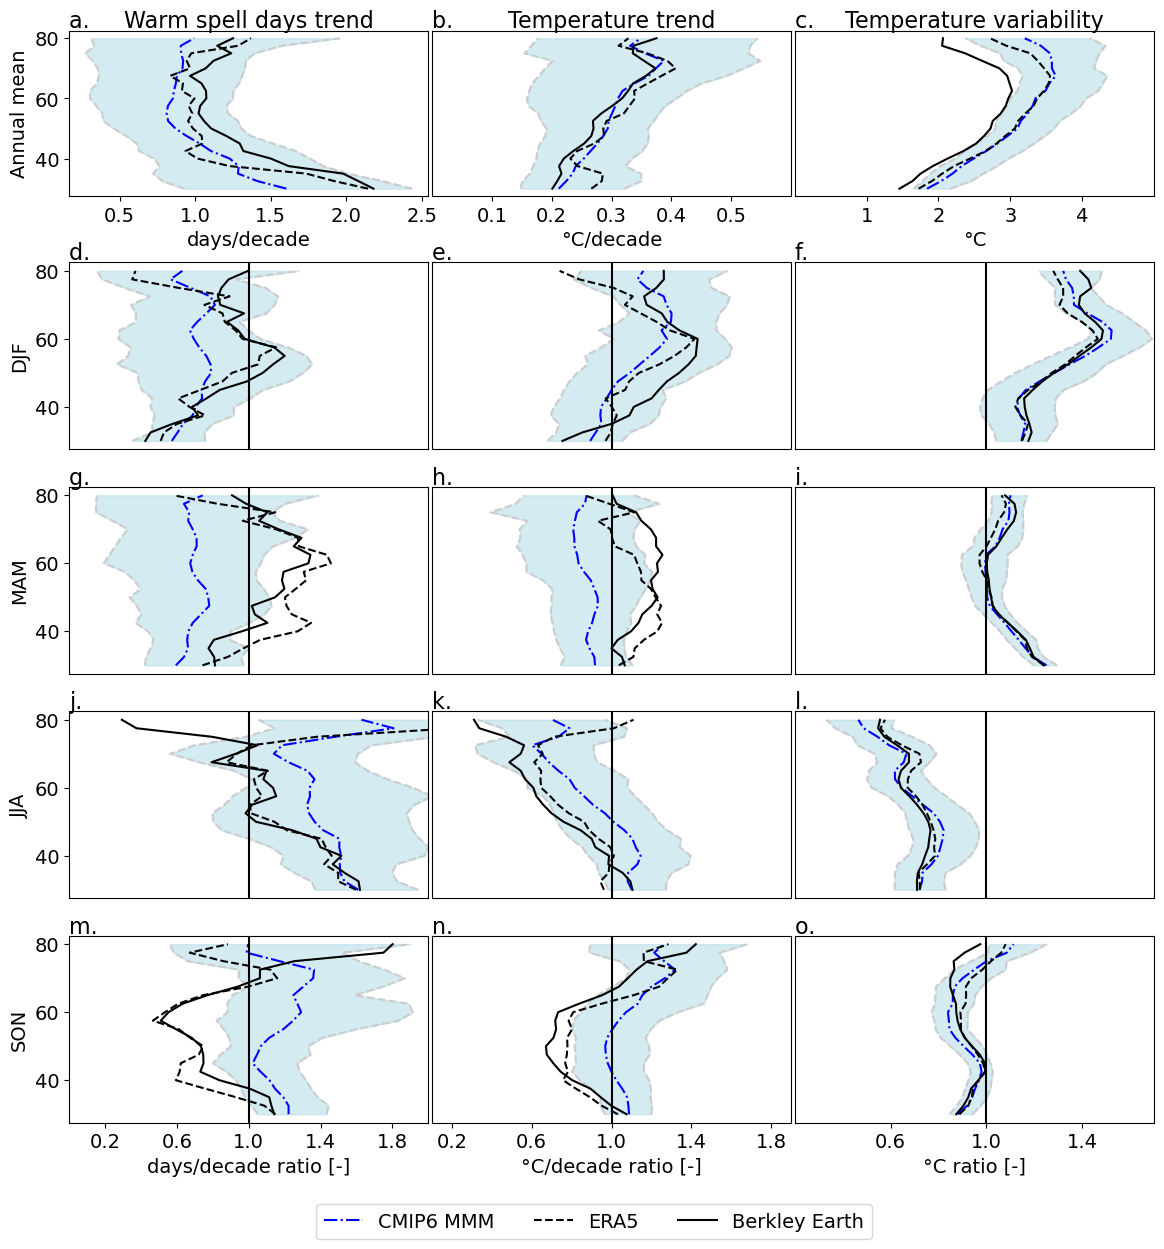

In [61]:
#plot together
fig=plt.figure(figsize=(14,14))
order=np.array([0,2,1,3])


main_gs = fig.add_gridspec(5, 3, hspace=0.4)
gs_row1 = main_gs[0,:].subgridspec(1, 3)
ax=fig.add_subplot(gs_row1[0, 0])
i=0
lat=trend_ann_cmip_mean.latitude
ax.plot(trend_ann_cmip_mean,lat,linestyle='-.',  color='blue', label='CMIP6 MMM')
ax.plot(trend_ann_cmip_upper,lat,linestyle='--', color='0.8')
ax.plot(trend_ann_cmip_lower,lat,linestyle='--', color='0.8')
ax.fill_betweenx(lat,trend_ann_cmip_lower, trend_ann_cmip_upper, color='lightblue', alpha=0.5)

ax.plot(trend_ann_era,lat,linestyle='--', color='black', label='ERA5')
ax.plot(trend_ann_bk,lat, color='black', label='Berkley Earth')
ax.set_title(letters[0],loc='left',fontsize=16, y=0.97)
if i==0:
    ax.set_title('Warm spell days trend',fontsize=16, y=0.97)
else:
    ax.set_title('')

ax.set_ylabel('Annual mean',fontsize=14)
ax.set_xlabel('days/decade',fontsize=14)

# if i<3:
#     ax.set_xticks([])
# else:
#     ax.set_xticks([-0.01,-0.005,0,0.005,0.01])
#     ax.set_xticklabels([-0.01,-0.005,0,0.005,0.01])
# ax.set_xlim([-0.01,0.01])
#plt.legend()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

ax=fig.add_subplot(gs_row1[0, 1])
lat=tmptrend_ann_cmip_mean.latitude
ax.plot(tmptrend_ann_cmip_mean,lat,linestyle='-.',  color='blue', label='CMIP6 MMM')
ax.plot(tmptrend_ann_cmip_upper,lat,linestyle='--', color='0.8')
ax.plot(tmptrend_ann_cmip_lower,lat,linestyle='--', color='0.8')
ax.fill_betweenx(lat,tmptrend_ann_cmip_lower, tmptrend_ann_cmip_upper, color='lightblue', alpha=0.5)

ax.plot(tmptrend_ann_era,lat,linestyle='--', color='black', label='ERA5')
ax.plot(tmptrend_ann_bk,lat, color='black', label='Berkley Earth')
ax.set_title(letters[4*i+1],loc='left',fontsize=16, y=0.97)
if i==0:
    ax.set_title('Temperature trend',fontsize=16, y=0.97)
else:
    ax.set_title('')
ax.set_xlabel('\u00B0C/decade',fontsize=14)

ax.set_xlim([0,0.6])
ax.set_yticks([])
ax.set_xticks(np.arange(0.1,0.6,0.1))
plt.xticks(fontsize=14)
# if i<3:
#     ax.set_xticks([])
#ax.set_xlim([-0.25,0.25])

#plt.legend()

ax=fig.add_subplot(gs_row1[0, 2])
lat=var_ann_cmip_mean.latitude
ax.plot(var_ann_cmip_mean,lat,linestyle='-.',  color='blue', label='CMIP6 MMM')
ax.plot(var_ann_cmip_upper,lat,linestyle='--', color='0.8')
ax.plot(var_ann_cmip_lower,lat,linestyle='--', color='0.8')
ax.fill_betweenx(lat,var_ann_cmip_lower, var_ann_cmip_upper, color='lightblue', alpha=0.5)

ax.plot(var_ann_era,lat, linestyle='--', color='black', label='ERA5')
ax.plot(var_ann_bk,lat,color='black', label='Berkley Earth')
ax.set_title(letters[4*i+2],loc='left',fontsize=16, y=0.97)
if i==0:
    ax.set_title('Temperature variability',fontsize=16, y=0.97)
else:
    ax.set_title('')

ax.set_xlabel('\u00B0C',fontsize=14)
ax.set_yticks([])
ax.set_xlim([0,5])
ax.set_xticks(np.arange(1,5,1))
plt.xticks(fontsize=14)


gs_row2 = main_gs[1:,:].subgridspec(4, 3, hspace=0.2) 
if i==3:
    plt.legend()


for i,ss in enumerate(titles):
    ax=fig.add_subplot(gs_row2[i,0])
    
    trend_dif_cmip_mean
    lat=trend_dif_cmip_mean.latitude
    ax.plot(trend_dif_cmip_mean.isel(season=order[i]),lat,linestyle='-.',  color='blue', label='CMIP6 MMM')
    ax.plot(trend_dif_cmip_upper.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.plot(trend_dif_cmip_lower.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,trend_dif_cmip_lower.isel(season=order[i]), trend_dif_cmip_upper.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(1,color='k')
    ax.plot(trend_dif_era.isel(season=order[i]),lat, linestyle='--', color='black', label='ERA5')
    ax.plot(trend_dif_bk.isel(season=order[i]),lat, color='black', label='Berkley Earth')
    ax.set_title(letters[3*i+3],loc='left',fontsize=16, y=0.97)
    ax.set_title('')
#     if i==0:
#         ax.set_title('Hot spell trend',fontsize=12, y=0.97)
#     else:
#         ax.set_title('')

    ax.set_ylabel(titles[order[i]], fontsize=14)
    ax.set_xlim([0,2])
    plt.yticks(np.arange(40,100,20),fontsize=14)
    if i<3:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(0.2,2,0.4))
        plt.xticks(fontsize=14)
        ax.set_xlabel('days/decade ratio [-]',fontsize=14)
        #ax.set_xticklabels([-0.01,-0.005,0,0.005,0.01])

    #plt.legend()
    
    
    ax=fig.add_subplot(gs_row2[i,1])
    lat=tmptrend_dif_cmip_mean.latitude
    ax.plot(tmptrend_dif_cmip_mean.isel(season=order[i]),lat,linestyle='-.',  color='blue', label='CMIP6 MMM')
    ax.plot(tmptrend_dif_cmip_upper.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.plot(tmptrend_dif_cmip_lower.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,tmptrend_dif_cmip_lower.isel(season=order[i]), tmptrend_dif_cmip_upper.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(1,color='k')
    ax.plot(tmptrend_dif_era.isel(season=order[i]),lat, linestyle='--', color='black', label='ERA5')
    ax.plot(tmptrend_dif_bk.isel(season=order[i]),lat,color='black', label='Berkley Earth')
    ax.set_title(letters[3*i+4],loc='left',fontsize=16, y=0.97)

    ax.set_title('')
    #     if i==0:
#         ax.set_title('Temperature trend',fontsize=12, y=0.97)
#     else:
#         ax.set_title('')

    ax.set_yticks([])
    plt.yticks(fontsize=14)
    ax.set_xlim([0.1,1.9])
    if i<3:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(0.2,1.9,0.4))
        plt.xticks(fontsize=14)
        ax.set_xlabel('\u00B0C/decade ratio [-]',fontsize=14)
    
    #plt.legend()
    
    ax=fig.add_subplot(gs_row2[i,2])
    lat=var_dif_cmip_mean.latitude
    ax.plot(var_dif_cmip_mean.isel(season=order[i]),lat,linestyle='-.',  color='blue', label='CMIP6 MMM')
    ax.plot(var_dif_cmip_upper.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.plot(var_dif_cmip_lower.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,var_dif_cmip_lower.isel(season=order[i]), var_dif_cmip_upper.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(1,color='k')
    ax.plot(var_dif_era.isel(season=order[i]),lat, linestyle='--', color='black', label='ERA5')
    ax.plot(var_dif_bk.isel(season=order[i]),lat,color='black', label='Berkley Earth')
    ax.set_title(letters[3*i+5],loc='left',fontsize=16, y=0.97)

    ax.set_title('')
    #     if i==0:
#         ax.set_title('Temperature variability',fontsize=12, y=0.97)
#     else:
#         ax.set_title('')
    ax.set_yticks([])
    ax.set_xlim([0.2,1.7])
    if i<3:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(0.6,1.7,0.4))
        plt.xticks(fontsize=14)
        ax.set_xlabel('\u00B0C ratio [-]',fontsize=14)
    

handles=[]
labels=[]
h, l = ax.get_legend_handles_labels()
handles.extend(h)
labels.extend(l)
fig.legend(handles, labels,ncol=3, loc='lower center', fontsize=14, bbox_to_anchor=(0.5, 0.01))  
plt.tight_layout()  
plt.subplots_adjust(hspace=0.35, wspace=0.01, bottom=0.1)
    
plt.savefig('plots_fix/parameters_latvar_main_erl.png')

In [23]:
#zonal dif (alb)
alseas_mn=xr.open_dataset('../ch3/mk_trends_albedo_cmip.nc')
alseas_mn=alseas_mn.assign_coords(model=alseas_mn.model)
alseas_mn_era=xr.open_dataset('../ch3/mk_trends_albedo_era.nc')

alseas_alb=alseas_mn.__xarray_dataarray_variable__.copy(deep=True)
alseasera_alb=alseas_mn_era.__xarray_dataarray_variable__.copy(deep=True)
# alseasbk_alb=alseas_mn_bk.copy(deep=True)

albtrend_annual_mn2=alseas_alb.mean(dim='season')
albtrend_annual_mn2_era=alseasera_alb.mean(dim='season')
#albtrend_annual_mn2_bk=alseasbk_alb.mean(dim='season')

albtrend_ann_cmip=albtrend_annual_mn2.mean(dim=['longitude'])*10
albtrend_ann_cmip_mean=albtrend_ann_cmip.mean(dim=['model'])
albtrend_ann_cmip_upper=albtrend_ann_cmip.quantile(0.975,dim='model')
albtrend_ann_cmip_lower=albtrend_ann_cmip.quantile(0.025,dim='model')

albtrend_dif_cmip=((alseas_alb-albtrend_annual_mn2).mean(dim='longitude'))*10
albtrend_dif_cmip_mean=albtrend_dif_cmip.mean(dim='model')
albtrend_dif_cmip_upper=albtrend_dif_cmip.quantile(0.975,dim='model')
albtrend_dif_cmip_lower=albtrend_dif_cmip.quantile(0.025,dim='model')

albtrend_ann_era=albtrend_annual_mn2_era.mean(dim='longitude')*10
albtrend_dif_era=((alseasera_alb - albtrend_annual_mn2_era).mean(dim='longitude'))*10
# albtrend_ann_bk=albtrend_annual_mn2_bk.mean(dim='longitude')*10
# albtrend_dif_bk=((alseasbk_alb - albtrend_annual_mn2_bk).mean(dim='longitude'))*10

In [24]:
#zonal dif (sm)
smseas_mn=xr.open_dataset('../ch3/mk_trends_soilmoisture_cmip.nc')
smseas_mn=smseas_mn.assign_coords(model=smseas_mn.model)
smseas_mn_era=xr.open_dataset('../ch3/mk_trends_soilmoisture_era.nc')

smseas_sm=smseas_mn.mrsos.copy(deep=True)
smseasera_sm=smseas_mn_era.swvl1.copy(deep=True)
# smseasbk_sm=smseas_mn_bk.copy(deep=True)

smtrend_annual_mn2=smseas_sm.mean(dim='season')
smtrend_annual_mn2_era=smseasera_sm.mean(dim='season')
#smtrend_annual_mn2_bk=smseasbk_sm.mean(dim='season')

smtrend_ann_cmip=smtrend_annual_mn2.mean(dim=['longitude'])*10
smtrend_ann_cmip_mean=smtrend_ann_cmip.mean(dim=['model'])
smtrend_ann_cmip_upper=smtrend_ann_cmip.quantile(0.975,dim='model')
smtrend_ann_cmip_lower=smtrend_ann_cmip.quantile(0.025,dim='model')

smtrend_dif_cmip=((smseas_sm-smtrend_annual_mn2).mean(dim='longitude'))*10
smtrend_dif_cmip_mean=smtrend_dif_cmip.mean(dim='model')
smtrend_dif_cmip_upper=smtrend_dif_cmip.quantile(0.975,dim='model')
smtrend_dif_cmip_lower=smtrend_dif_cmip.quantile(0.025,dim='model')

smtrend_ann_era=smtrend_annual_mn2_era.mean(dim='longitude')*10
smtrend_dif_era=((smseasera_sm - smtrend_annual_mn2_era).mean(dim='longitude'))*10
# smtrend_ann_bk=smtrend_annual_mn2_bk.mean(dim='longitude')*10
# smtrend_dif_bk=((smseasbk_sm - smtrend_annual_mn2_bk).mean(dim='longitude'))*10

In [34]:
#zonal dif (tmp)
trseas_tmp=trseas_mn.copy(deep=True)
trseasera_tmp=trseas_mn_era.copy(deep=True)
trseasbk_tmp=trseas_mn_bk.copy(deep=True)

tmptrend_annual_mn2=trseas_tmp.mean(dim='season')
tmptrend_annual_mn2_era=trseasera_tmp.mean(dim='season')
tmptrend_annual_mn2_bk=trseasbk_tmp.mean(dim='season')

tmptrend_ann_cmip=tmptrend_annual_mn2.mean(dim=['longitude'])*10
tmptrend_ann_cmip_mean=tmptrend_ann_cmip.mean(dim=['models'])
tmptrend_ann_cmip_upper=tmptrend_ann_cmip.quantile(0.975,dim='models')
tmptrend_ann_cmip_lower=tmptrend_ann_cmip.quantile(0.025,dim='models')

tmptrend_dif_cmip=((trseas_tmp-tmptrend_annual_mn2).mean(dim='longitude'))*10
tmptrend_dif_cmip_mean=tmptrend_dif_cmip.mean(dim='models')
tmptrend_dif_cmip_upper=tmptrend_dif_cmip.quantile(0.975,dim='models')
tmptrend_dif_cmip_lower=tmptrend_dif_cmip.quantile(0.025,dim='models')

tmptrend_ann_era=tmptrend_annual_mn2_era.mean(dim='longitude')*10
tmptrend_dif_era=((trseasera_tmp - tmptrend_annual_mn2_era).mean(dim='longitude'))*10
tmptrend_ann_bk=tmptrend_annual_mn2_bk.mean(dim='longitude')*10
tmptrend_dif_bk=((trseasbk_tmp - tmptrend_annual_mn2_bk).mean(dim='longitude'))*10

In [ ]:
#plot together
fig=plt.figure(figsize=(14,10))
order=np.array([0,2,1,3])

i=0

# if i<3:
#     ax.set_xticks([])
# else:
#     ax.set_xticks([-0.01,-0.005,0,0.005,0.01])
#     ax.set_xticklabels([-0.01,-0.005,0,0.005,0.01])
# ax.set_xlim([-0.01,0.01])
#plt.legend()


ax=fig.add_subplot(5,3,1)
lat=albtrend_ann_cmip_mean.latitude
ax.plot(albtrend_ann_cmip_mean,lat,  color='blue', label='CMIP6 MMM')
ax.plot(albtrend_ann_cmip_upper,lat,linestyle='--', color='0.8')
ax.plot(albtrend_ann_cmip_lower,lat,linestyle='--', color='0.8')
ax.fill_betweenx(lat,albtrend_ann_cmip_lower, albtrend_ann_cmip_upper, color='lightblue', alpha=0.5)

ax.plot(albtrend_ann_era,lat, color='black',linestyle='-.', label='ERA5')
#ax.plot(albtrend_ann_bk,lat,linestyle='--', color='black', label='Berkley Earth')
ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.97)
if i==0:
    ax.set_title('Albedo trend', fontsize=16, y=0.97)
else:
    ax.set_title('')
ax.set_yticks([40,60,80])
#ax.set_yticklabels(['40','60','80'], fontsize=14)
ax.set_xticks(np.arange(-0.01,0.01,0.005))
ax.tick_params(axis='both', which='major', labelsize=14)

#ax.set_xticks(np.arange(0,0.6,0.1))
# if i<3:
#     ax.set_xticks([])
ax.set_xlim([-0.011,0.001])
ax.set_ylabel('Annual', fontsize=14)
#plt.legend()



ax=fig.add_subplot(5,3,2)
lat=smtrend_ann_cmip_mean.latitude
ax.plot(smtrend_ann_cmip_mean,lat,  color='blue', label='CMIP6 MMM')
ax.plot(smtrend_ann_cmip_upper,lat,linestyle='--', color='0.8')
ax.plot(smtrend_ann_cmip_lower,lat,linestyle='--', color='0.8')
ax.fill_betweenx(lat,smtrend_ann_cmip_lower, smtrend_ann_cmip_upper, color='lightblue', alpha=0.5)

ax.plot(smtrend_ann_era,lat, color='black',linestyle='-.', label='ERA5')
#ax.plot(smtrend_ann_bk,lat,linestyle='--', color='black', label='Berkley Earth')
ax.set_title(letters[3*i+1],loc='left', fontsize=16, y=0.97)
if i==0:
    ax.set_title('Soil moisture trend', fontsize=16, y=0.97)
else:
    ax.set_title('')
ax.tick_params(axis='x', labelsize=14)
ax.set_yticks([])
#ax.set_xticks(np.arange(0,0.6,0.1))
# if i<3:
#     ax.set_xticks([])
ax=fig.add_subplot(5,3,3)

lat=tmptrend_ann_cmip_mean.latitude
ax.plot(tmptrend_ann_cmip_mean,lat,  color='blue', label='CMIP6 MMM')
ax.plot(tmptrend_ann_cmip_upper,lat,linestyle='--', color='0.8')
ax.plot(tmptrend_ann_cmip_lower,lat,linestyle='--', color='0.8')
ax.fill_betweenx(lat,tmptrend_ann_cmip_lower, tmptrend_ann_cmip_upper, color='lightblue', alpha=0.5)

ax.plot(tmptrend_ann_era,lat, color='black',linestyle='-.', label='ERA5')
#ax.plot(tmptrend_ann_bk,lat,linestyle='--', color='black', label='Berkley Earth')
ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.97)
if i==0:
    ax.set_title('Temperature trend',fontsize=16, y=0.97)
else:
    ax.set_title('')

ax.tick_params(axis='x', labelsize=14)
ax.set_yticks([])

if i==3:
    plt.legend()

titles=tmptrend_dif_cmip_mean.season.values

for i,ss in enumerate(titles):
   
    #plt.legend()
    
    
    
    ax=fig.add_subplot(5,3,3*i+4)
    lat=albtrend_dif_cmip_mean.latitude
    ax.plot(albtrend_dif_cmip_mean.isel(season=order[i]),lat,  color='blue', label='CMIP6 MMM')
    ax.plot(albtrend_dif_cmip_upper.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.plot(albtrend_dif_cmip_lower.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,albtrend_dif_cmip_lower.isel(season=order[i]), albtrend_dif_cmip_upper.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(color='k')
    ax.plot(albtrend_dif_era.isel(season=order[i]),lat, color='black',linestyle='-.', label='ERA5')
    #ax.plot(albtrend_dif_bk.isel(season=order[i]),lat,linestyle='--', color='black', label='Berkley Earth')
    ax.set_title(letters[3*i+3],loc='left',fontsize=16, y=0.97)
    ax.set_ylabel(titles[order[i]], fontsize=14)
    ax.set_yticks([40,60,80])
    ax.set_yticklabels(['40','60','80'], fontsize=14)

    ax.set_title('')
    
    
    if i<3:
        ax.set_xticks([])
    else:
        ticks=np.arange(-0.006,0.008,0.003)
        #tickstr=[f"{ticks[0]:.1e}", f"{ticks[1]:.1e}", f"{ticks[2]:.1e}", f"{ticks[3]:.1e}", f"{ticks[4]:.1e}"]
        tickstr=[str(ticks[0]),str(ticks[1]), str(ticks[2]), str(ticks[3]), str(ticks[4])]
        ax.set_xticks(ticks)
        #ax.set_xticklabels(tickstr,fontsize=14)
        ax.tick_params(axis='x', labelsize=14)
        ax.set_xlabel('albedo [-]', fontsize=14)
    ax.set_xlim([-0.008,0.008])
    
    #plt.legend()
    
    
    
    #plt.legend()
    
    ax=fig.add_subplot(5,3,3*i+5)
    lat=smtrend_dif_cmip_mean.latitude
    ax.plot(smtrend_dif_cmip_mean.isel(season=order[i]),lat,  color='blue', label='CMIP6 MMM')
    ax.plot(smtrend_dif_cmip_upper.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.plot(smtrend_dif_cmip_lower.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,smtrend_dif_cmip_lower.isel(season=order[i]), smtrend_dif_cmip_upper.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(color='k')
    ax.plot(smtrend_dif_era.isel(season=order[i]),lat, color='black', linestyle='-.',label='ERA5')
    #ax.plot(smtrend_dif_bk.isel(season=order[i]),lat,linestyle='--', color='black', label='Berkley Earth')
    ax.set_title(letters[3*i+4],loc='left',fontsize=16, y=0.97)
    
    ax.set_title('')


    ax.set_yticks([])
    if i<3:
        ax.set_xticks([])
    ax.set_xlim([-0.3,0.3])
    
    #plt.legend()
    if i<3:
        ax.set_xticks([])
    else:
        ticks=np.arange(-0.2,0.3,0.1)
        #tickstr=[f"{ticks[0]:.1e}", f"{ticks[1]:.1e}", f"{ticks[2]:.1e}", f"{ticks[3]:.1e}", f"{ticks[4]:.1e}"]
#         tickstr=['-0.2','']
        ax.set_xticks(ticks)
        ax.tick_params(axis='x', labelsize=14)
        ax.set_xlabel('soil moisture [kg/m\u00b2]', fontsize=14)
        
    ax=fig.add_subplot(5,3,3*i+6)
    lat=tmptrend_dif_cmip_mean.latitude
    ax.plot(tmptrend_dif_cmip_mean.isel(season=order[i]),lat,  color='blue', label='CMIP6 MMM')
    ax.plot(tmptrend_dif_cmip_upper.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.plot(tmptrend_dif_cmip_lower.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,tmptrend_dif_cmip_lower.isel(season=order[i]), tmptrend_dif_cmip_upper.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(color='k')
    ax.plot(tmptrend_dif_era.isel(season=order[i]),lat, color='black',linestyle='-.', label='ERA5')
    #ax.plot(tmptrend_dif_bk.isel(season=order[i]),lat,linestyle='--', color='black', label='Berkley Earth')
    ax.set_title(letters[3*i+5],loc='left',fontsize=16, y=0.97)

    ax.set_title('')
    
    ax.set_yticks([])
    #ax.set_yticks([])
    if i<3:
        ax.set_xticks([])
    else:
        ticks=np.arange(-0.2,0.3,0.1)
        tickstr=[str(ticks[0]),str(ticks[1]), str(ticks[2]), str(ticks[3]), str(ticks[4])]
        ax.set_xticks(ticks)
        #ax.set_xticklabels(tickstr,fontsize=14)
        ax.tick_params(axis='x', labelsize=14)
        ax.set_xlabel('temperature [\u00b0C]', fontsize=14)
    ax.set_xlim([-0.25,0.25])
    
    
    if i==3:
        plt.legend()
plt.tight_layout()  
plt.subplots_adjust(hspace=0.3, wspace=0.01)
    
plt.savefig('plots_fix/landparams_latvar_main_erl.png')

In [62]:
#zonal dif (snw)
snowseas_mn=xr.open_dataset('../ch3/mk_trends_snowdepth_cmip.nc')
snowseas_mn=snowseas_mn.assign_coords(model=snowseas_mn.model)
snowseas_mn_era=xr.open_dataset('../ch3/mk_trends_snowdepth_era.nc')

snowseas_snw=snowseas_mn.snd.copy(deep=True)
snowseasera_snw=snowseas_mn_era.sd.copy(deep=True)
# snowseasbk_snw=snowseas_mn_bk.copy(deep=True)

snwtrend_annual_mn2=snowseas_snw.mean(dim='season')
snwtrend_annual_mn2_era=snowseasera_snw.mean(dim='season')
#snwtrend_annual_mn2_bk=snowseasbk_snw.mean(dim='season')

snwtrend_ann_cmip=snwtrend_annual_mn2.mean(dim=['longitude'])*10
snwtrend_ann_cmip_mean=snwtrend_ann_cmip.mean(dim=['model'])
snwtrend_ann_cmip_upper=snwtrend_ann_cmip.quantile(0.975,dim='model')
snwtrend_ann_cmip_lower=snwtrend_ann_cmip.quantile(0.025,dim='model')

snwtrend_dif_cmip=((snowseas_snw-snwtrend_annual_mn2).mean(dim='longitude'))*10
snwtrend_dif_cmip_mean=snwtrend_dif_cmip.mean(dim='model')
snwtrend_dif_cmip_upper=snwtrend_dif_cmip.quantile(0.975,dim='model')
snwtrend_dif_cmip_lower=snwtrend_dif_cmip.quantile(0.025,dim='model')

snwtrend_ann_era=snwtrend_annual_mn2_era.mean(dim='longitude')*10
snwtrend_dif_era=((snowseasera_snw - snwtrend_annual_mn2_era).mean(dim='longitude'))*10
# snwtrend_ann_bk=snwtrend_annual_mn2_bk.mean(dim='longitude')*10
# snwtrend_dif_bk=((snowseasbk_snw - snwtrend_annual_mn2_bk).mean(dim='longitude'))*10

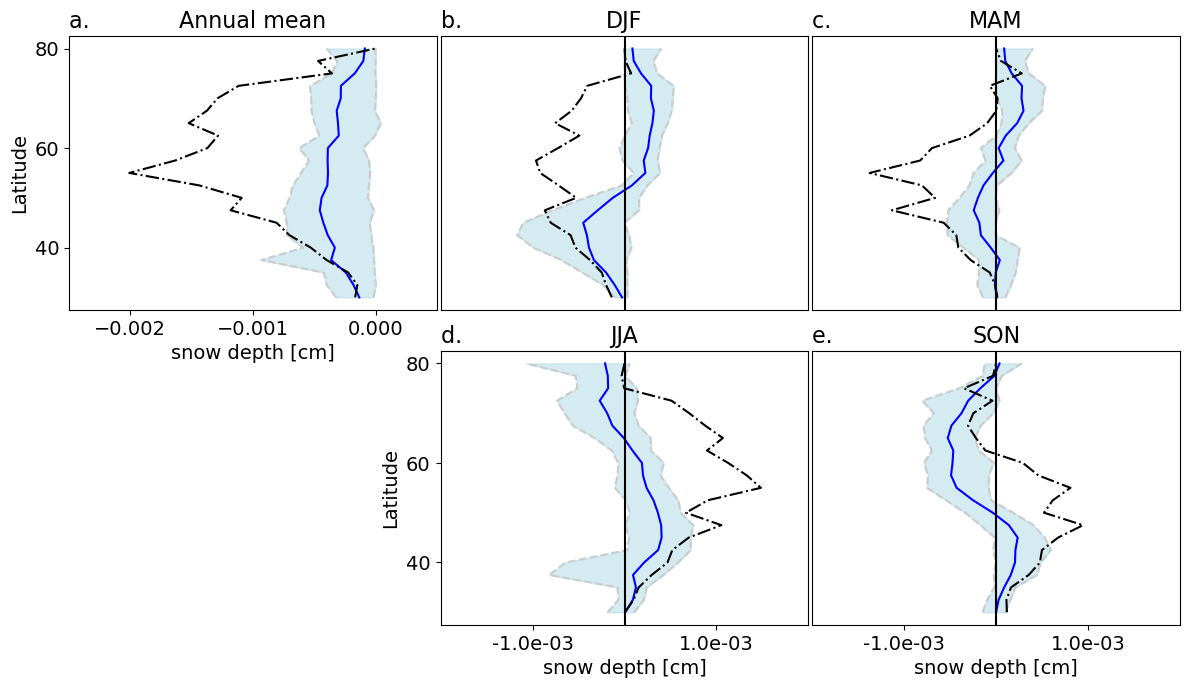

In [70]:
#plot snow
fig=plt.figure(figsize=(12,7))
order=np.array([0,2,1,3])
ax=fig.add_subplot(2,3,1)
lat=snwtrend_ann_cmip_mean.latitude
ax.plot(snwtrend_ann_cmip_mean,lat,  color='blue', label='CMIP6 MMM')
ax.plot(snwtrend_ann_cmip_upper,lat,linestyle='--', color='0.8')
ax.plot(snwtrend_ann_cmip_lower,lat,linestyle='--', color='0.8')
ax.fill_betweenx(lat,snwtrend_ann_cmip_lower, snwtrend_ann_cmip_upper, color='lightblue', alpha=0.5)

ax.plot(snwtrend_ann_era,lat, color='black',linestyle='-.', label='ERA5')
#ax.plot(snwtrend_ann_bk,lat,linestyle='--', color='black', label='Berkley Earth')
ax.set_title(letters[0],loc='left', fontsize=16, )
# if i==0:
#     ax.set_title('Snow depth trend', fontsize=16,)
# else:
#     ax.set_title('')
ax.tick_params(axis='x', labelsize=14)
ax.set_yticks(np.arange(40,100,20))
ax.set_xticks(np.arange(-0.002,0.001,0.001))
ax.set_title('Annual mean',fontsize=16)
ax.set_ylabel('Latitude', fontsize=14)
plt.yticks(fontsize=14)
# if i<3:
#     ax.set_xticks([])
ax.set_xlim([-0.0025,0.0005])
ax.set_xlabel('snow depth [cm]', fontsize=14)

for i,ss in enumerate(titles):
    if i>1:
        ax=fig.add_subplot(2,3,i+3)
    else:
        ax=fig.add_subplot(2,3,i+2)
    lat=snwtrend_dif_cmip_mean.latitude
    ss=snwtrend_dif_cmip_mean.isel(season=order[i]).season.values
    ax.plot(snwtrend_dif_cmip_mean.isel(season=order[i]),lat,  color='blue', label='CMIP6 MMM')
    ax.plot(snwtrend_dif_cmip_upper.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.plot(snwtrend_dif_cmip_lower.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,snwtrend_dif_cmip_lower.isel(season=order[i]), snwtrend_dif_cmip_upper.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(color='k')
    ax.plot(snwtrend_dif_era.isel(season=order[i]),lat, color='black',linestyle='-.', label='ERA5')
    #ax.plot(snwtrend_dif_bk.isel(season=order[i]),lat,linestyle='--', color='black', label='Berkley Earth')
    ax.set_title(letters[i+1],loc='left',fontsize=16)
    ax.set_title(ss,fontsize=16)
    ax.set_yticks([])

    if i==2:
        ax.set_yticks(np.arange(40,100,20))
        plt.yticks(fontsize=14)
        ax.set_ylabel('Latitude', fontsize=14)
    
    if i<2:
        ax.set_xticks([])
    else:
        ticks=np.arange(-0.001,0.002,0.002)
        tickstr=[f"{ticks[0]:.1e}", f"{ticks[1]:.1e}"]
        ax.set_xticks(ticks)
        ax.set_xticklabels(tickstr, fontsize=14)
        #ax.tick_params(axis='x', labelsize=14)
        ax.set_xlabel('snow depth [cm]', fontsize=14)
    ax.set_xlim([-0.002,0.002])
plt.tight_layout()  
plt.subplots_adjust(hspace=0.15, wspace=0.01, bottom=0.1)
plt.savefig('plots_fix/snow_depth_trends_supporting.png')

## SON-MAM

In [57]:
#latvar variability
def sonmam(dat):
    dat1=dat.sel(season='MAM').mean(dim=['latitude','longitude'])-dat.sel(season='SON').mean(dim=['latitude','longitude'])
    return dat1

def sonmam2(dat):
    dat1=dat.sel(season='MAM')-dat.sel(season='SON')
    dat2=dat1.stack(z={'latitude','longitude'})
    return dat1

y=sonmam(trseas_heat) 
y1=sonmam(trseasera_heat) 
y2=sonmam(trseasbk_heat) 

xtmp=sonmam(trseas_tmp)
xtmpera=sonmam(trseasera_tmp)
xtmpbk=sonmam(trseasbk_tmp)

xvar=sonmam(trseas_var)
xvarera=sonmam(trseasera_var)
xvarbk=sonmam(trseasbk_var)


xvarcor=trseas_tmp/trseas_var
xtmp_var=sonmam(xvarcor)
xvarcor1=trseasera_tmp/trseasera_var
xtmp_varera=sonmam(xvarcor1)
xvarcor2=trseasbk_tmp/trseasbk_var
xtmp_varbk=sonmam(xvarcor2)

In [58]:
#albedo and soil moisture
models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models=np.array(models1+models22)
len(models)
trseas_heat=trseas_heat.assign_coords(models=models)
models_alb=np.array(['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM'])
alseas_alb=alseas_alb.assign_coords(model=models_alb).rename({'model':'models'})
models_mrso=np.array(['BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2-WACCM','CESM2','CMCC-CM2-SR5','CMCC-ESM2','CNRM-CM6-1-HR','E3SM-1-1','EC-Earth3-CC','EC-Earth3-Veg-LR', 'MIROC6',  'MIROC-ES2L', 'MPI-ESM1-2-LR','MRI-ESM2-0','NorESM2-LM','NorESM2-MM','TaiESM1'])
smseas_sm=smseas_sm.assign_coords(model=models_mrso).rename({'model':'models'})

In [59]:
#shared models
models_albsh=models_alb[np.isin(models_alb,models)]
alseas_alb=alseas_alb.sel(models=models_albsh)
xalb=sonmam(alseas_alb)
xalbera=sonmam(alseasera_alb)
# xvartrbk=sonmam(trseasbk_vartr)
tmpalb=trseas_heat.sel(models=models_albsh)
yalb=sonmam(tmpalb) 

models_smsh=models_mrso[np.isin(models_mrso,models)]
smseas_sm=smseas_sm.sel(models=models_smsh)
xsm=sonmam(smseas_sm)
xsmera=sonmam(smseasera_sm)
tmpsm=trseas_heat.sel(models=models_smsh)
ysm=sonmam(tmpsm) 

In [60]:
def sonmam2(dat):
    dat1=dat.sel(season='MAM')-dat.sel(season='SON')
    dat2=dat1.stack(z={'latitude','longitude'})
    
    datup=dat2.quantile(0.975,dim='z')
    datlow=dat2.quantile(0.025,dim='z')
    return datup,datlow

def sonmam(dat):
    dat1=dat.sel(season='MAM').mean(dim=['latitude','longitude'])-dat.sel(season='SON').mean(dim=['latitude','longitude'])
    return dat1

yup,ylow=sonmam2(trseas_heat) 
yup1,y1low=sonmam2(trseasera_heat) 
yup2,y2low=sonmam2(trseasbk_heat) 



In [17]:
#prepare warm spell, temp, variability
def sonmam3(dat):
    dat1=dat.sel(season='MAM')-dat.sel(season='SON')
    dat2=dat1.stack(z={'latitude','longitude'})
    
    return dat2

yall=sonmam3(10*trseas_heat)
#xall_tmp=sonmam3(trseas_tmp)

yera_all=sonmam3(10*trseasera_heat)
#xeraall_tmp=sonmam3(trseasera_heat)

ybk_all=sonmam3(10*trseasbk_heat)
#xbkall_tmp=sonmam3(trseasbk_heat)

xtmp_all=sonmam3(10*trseas_tmp)
xtmpera_all=sonmam3(10*trseasera_tmp)
xtmpbk_all=sonmam3(10*trseasbk_tmp)

xvar_all=sonmam3(trseas_var)
xvarera_all=sonmam3(trseasera_var)
xvarbk_all=sonmam3(trseasbk_var)


xvarcor=10*trseas_tmp/trseas_var
xtmp_var_all=sonmam3(xvarcor)
xvarcor1=10*trseasera_tmp/trseasera_var
xtmp_varera_all=sonmam3(xvarcor1)
xvarcor2=10*trseasbk_tmp/trseasbk_var
xtmp_varbk_all=sonmam3(xvarcor2)



In [18]:
#model means (weighted)
lat_radians = np.deg2rad(xtmpera_all.unstack().latitude)
weights = np.cos(lat_radians)

y_weighted=yall.unstack().weighted(weights).mean(("longitude", "latitude"))
yera_weighted=yera_all.unstack().weighted(weights).mean(("longitude", "latitude"))
ybk_weighted=ybk_all.unstack().weighted(weights).mean(("longitude", "latitude"))

xtmp_weighted=xtmp_all.unstack().weighted(weights).mean(("longitude", "latitude"))
xtmpera_weighted=xtmpera_all.unstack().weighted(weights).mean(("longitude", "latitude"))
xtmpbk_weighted=xtmpbk_all.unstack().weighted(weights).mean(("longitude", "latitude"))

xtmp_var_weighted=xtmp_var_all.unstack().weighted(weights).mean(("longitude", "latitude"))
xtmp_varera_weighted=xtmp_varera_all.unstack().weighted(weights).mean(("longitude", "latitude"))
xtmp_varbk_weighted=xtmp_varbk_all.unstack().weighted(weights).mean(("longitude", "latitude"))

xvar_weighted=xvar_all.unstack().weighted(weights).mean(("longitude", "latitude"))
xvarera_weighted=xvarera_all.unstack().weighted(weights).mean(("longitude", "latitude"))
xvarbk_weighted=xvarbk_all.unstack().weighted(weights).mean(("longitude", "latitude"))



In [25]:
#albedo and soil moisture models
models1=['ACCESS-CM2','AWI-CM-1-1-MR','BCC-CSM2-MR', 'CanESM5','CESM2','CMCC-ESM2','CNRM-ESM2-1','EC-Earth3-CC','GFDL-ESM4','IITM-ESM','INM-CM5-0','KIOST-ESM','MIROC6','MPI-ESM1-2-LR','MRI-ESM2-0','NESM3','NorESM2-MM','TaiESM1']# temp_datcut={}
models22=['CESM2-WACCM', 'CMCC-CM2-SR5', 'CNRM-CM6-1','INM-CM4-8','IPSL-CM6A-LR', 'MIROC-ES2L','CNRM-CM6-1-HR']
models=np.array(models1+models22)
len(models)
trseas_heat=trseas_heat.assign_coords(models=models)
models_alb=np.array(['ACCESS-CM2', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'E3SM-1-1', 'FGOALS-g3', 'IITM-ESM',  'MIROC6', 'MPI-ESM1-2-LR', 'NESM3', 'NorESM2-MM'])
alseas_alb=alseas_alb.assign_coords(model=models_alb).rename({'model':'models'})
models_mrso=np.array(['BCC-CSM2-MR','CAMS-CSM1-0', 'CanESM5-CanOE', 'CESM2-WACCM','CESM2','CMCC-CM2-SR5','CMCC-ESM2','CNRM-CM6-1-HR','E3SM-1-1','EC-Earth3-CC','EC-Earth3-Veg-LR', 'MIROC6',  'MIROC-ES2L', 'MPI-ESM1-2-LR','MRI-ESM2-0','NorESM2-LM','NorESM2-MM','TaiESM1'])
smseas_sm=smseas_sm.assign_coords(model=models_mrso).rename({'model':'models'})

In [26]:
#shared models (albedo and soil moisture)
models_albsh=models_alb[np.isin(models_alb,models)]
alseas_alb=alseas_alb.sel(models=models_albsh)

tmpalb=trseas_heat.sel(models=models_albsh)
# yalb=sonmam(tmpalb) 

models_smsh=models_mrso[np.isin(models_mrso,models)]
smseas_sm=smseas_sm.sel(models=models_smsh)

tmpsm=trseas_heat.sel(models=models_smsh)
# ysm=sonmam(tmpsm) 

In [27]:
#prepare albedo and soil moisture
xalb_all=sonmam3(10*alseas_alb)
xalbera_all=sonmam3(10*alseasera_alb)
yalb_all=sonmam3(10*tmpalb)

xsm_all=sonmam3(10*smseas_sm)
xsm_era_all=sonmam3(10*smseasera_sm)
ysm_all=sonmam3(10*tmpsm)

xalb_weighted=xalb_all.unstack().weighted(weights).mean(("longitude", "latitude"))
xalbera_weighted=xalbera_all.unstack().weighted(weights).mean(("longitude", "latitude"))
yalb_weighted=yalb_all.unstack().weighted(weights).mean(("longitude", "latitude"))

xsm_weighted=xsm_all.unstack().weighted(weights).mean(("longitude", "latitude"))
xsmera_weighted=xsm_era_all.unstack().weighted(weights).mean(("longitude", "latitude"))
ysm_weighted=ysm_all.unstack().weighted(weights).mean(("longitude", "latitude"))

In [28]:
#weighted mean
lat_radians = np.deg2rad(xtmpera_all.unstack().sel(latitude=slice(30,60)).latitude)
weights1 = np.cos(lat_radians)
lat_radians2 = np.deg2rad(xtmpera_all.unstack().sel(latitude=slice(60,80)).latitude)
weights2 = np.cos(lat_radians2)
xalb_weighted1=xalb_all.unstack().sel(latitude=slice(30,60)).weighted(weights1).mean(("longitude", "latitude"))
xalbera_weighted1=xalbera_all.unstack().sel(latitude=slice(30,60)).weighted(weights1).mean(("longitude", "latitude"))
yera_weighted1=yera_all.unstack().sel(latitude=slice(30,60)).weighted(weights1).mean(("longitude", "latitude"))
yalb_weighted1=yalb_all.unstack().sel(latitude=slice(30,60)).weighted(weights1).mean(("longitude", "latitude"))


xalb_weighted2=xalb_all.unstack().sel(latitude=slice(60,80)).weighted(weights2).mean(("longitude", "latitude"))
xalbera_weighted2=xalbera_all.unstack().sel(latitude=slice(60,80)).weighted(weights2).mean(("longitude", "latitude"))
yera_weighted2=yera_all.unstack().sel(latitude=slice(60,80)).weighted(weights1).mean(("longitude", "latitude"))
yalb_weighted2=yalb_all.unstack().sel(latitude=slice(60,80)).weighted(weights2).mean(("longitude", "latitude"))

xalb_all1=xalb_all.unstack().sel(latitude=slice(30,60)).stack(z={'latitude','longitude'})
xalb_all2=xalb_all.unstack().sel(latitude=slice(60,80)).stack(z={'latitude','longitude'})

yalb_all1=yalb_all.unstack().sel(latitude=slice(30,60)).stack(z={'latitude','longitude'})
yalb_all2=yalb_all.unstack().sel(latitude=slice(60,80)).stack(z={'latitude','longitude'})

xalbera_all1=xalbera_all.unstack().sel(latitude=slice(30,60)).stack(z={'latitude','longitude'})
xalbera_all2=xalbera_all.unstack().sel(latitude=slice(60,80)).stack(z={'latitude','longitude'})

yalbera_all1=yera_all.unstack().sel(latitude=slice(30,60)).stack(z={'latitude','longitude'})
yalbera_all2=yera_all.unstack().sel(latitude=slice(60,80)).stack(z={'latitude','longitude'})

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

<Figure size 1800x1000 with 0 Axes>

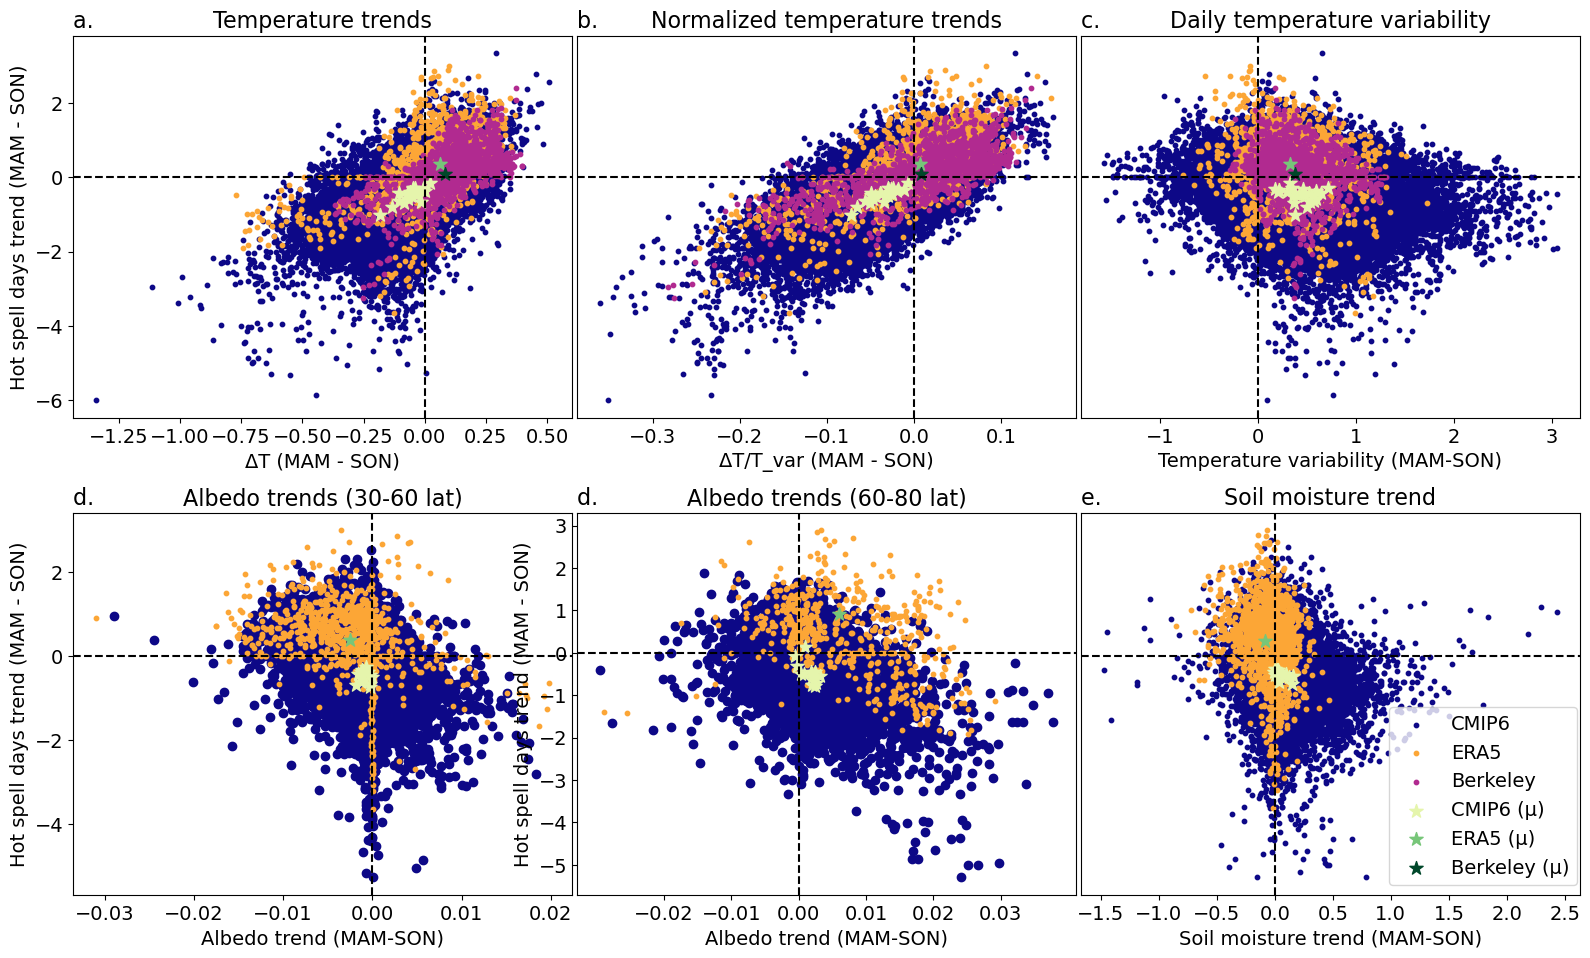

In [85]:
#plot
fig=plt.figure(figsize=(18,10))
plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
nums=np.linspace(0,1,18)
# ax=fig.add_subplot(331)
# for i in range(18):
#     ax.scatter(xall.isel(models=i),yall.isel(models=i),c=cmap(nums[i]))
# ax.scatter(xeraall,yeraall,c='k')
# ax.scatter(xbkall,ybkall,c='0.05')

# #plot
# ## plot
fig=plt.figure(figsize=(16,10))
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')

ax1=fig.add_subplot(231)
for i in range(25):
    if i==0:
        ax1.scatter(xtmp_all.isel(models=i),yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
    else:
        ax1.scatter(xtmp_all.isel(models=i),yall.isel(models=i), s=10, alpha=1,c=cmap(0))
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax1.scatter(xtmpera_all,yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
ax1.scatter(xtmpbk_all,ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')

ax1.scatter(xtmp_weighted,y_weighted,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax1.scatter(xtmpera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
ax1.scatter(xtmpbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')


ax1.set_title('Temperature trends', fontsize=16)
ax1.set_ylabel('Hot spell days trend (MAM - SON)', fontsize=14)
ax1.set_xlabel(u'ΔT (MAM - SON)', fontsize=14)
ax1.axhline(color='k', linestyle='--')
ax1.axvline(color='k', linestyle='--')
ax1.set_title(letters[0],loc='left',fontsize=16)

# ax.set_xticks(np.arange(-0.12,0.05,0.04))

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax=fig.add_subplot(232)
for i in range(25):
    ax.scatter(xtmp_var_all.isel(models=i),yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')

ax.scatter(xtmp_varera_all,yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')

ax.scatter(xtmp_varbk_all,ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')


ax.scatter(xtmp_var_weighted,y_weighted,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax.scatter(xtmp_varera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
ax.scatter(xtmp_varbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')


ax.set_title('Normalized temperature trends', fontsize=16)
#ax.set_ylabel('Heatdays trend', fontsize=12)
ax.set_xlabel(u'ΔT/T_var (MAM - SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_yticks([])
ax.set_title(letters[1],loc='left',fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax=fig.add_subplot(233)
for i in range(25):
    ax.scatter(xvar_all.isel(models=i),yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')#cmap(nums[i])
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax.scatter(xvarera_all,yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
ax.scatter(xvarbk_all,ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')


ax.scatter(xvar_weighted,y_weighted,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax.scatter(xvarera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
ax.scatter(xvarbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')

ax.set_title('Daily temperature variability', fontsize=16)
#ax.set_ylabel('Heatdays trend', fontsize=12)
ax.set_yticks([])
ax.set_xlabel('Temperature variability (MAM-SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_title(letters[2],loc='left',fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax=fig.add_subplot(234)
for i in range(len(models_albsh)):
    ax.scatter(xalb_all1.isel(models=i),yalb_all1.isel(models=i),c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax.scatter(xalbera_all1,yalbera_all1, s=10,c=cmap(0.8), label='ERA5')
#ax.scatter(xalbbk_all,ybk_all, s=10,c=cmap(0.4), label='Berkeley')

ax.scatter(xalb_weighted1,yalb_weighted1,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax.scatter(xalbera_weighted1,yera_weighted1,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
#ax.scatter(xalbbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')


ax.set_title('Albedo trends (30-60 lat)' , fontsize=16)
#ax.set_ylabel('Heatdays trend', fontsize=12)


ax.set_xlabel('Albedo trend (MAM-SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_title(letters[3],loc='left',fontsize=16)
ax.set_ylabel('Hot spell days trend (MAM - SON)', fontsize=14)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)


ax=fig.add_subplot(235)
for i in range(len(models_albsh)):
    ax.scatter(xalb_all2.isel(models=i),yalb_all2.isel(models=i),c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax.scatter(xalbera_all2,yalbera_all2, s=10,c=cmap(0.8), label='ERA5')
#ax.scatter(xalbbk_all,ybk_all, s=10,c=cmap(0.4), label='Berkeley')

ax.scatter(xalb_weighted2,yalb_weighted2,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax.scatter(xalbera_weighted2,yera_weighted2,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
#ax.scatter(xalbbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')

ax.set_xticks(np.arange(-0.02,0.04,0.01))
ax.set_title('Albedo trends (60-80 lat)' , fontsize=16)
#ax.set_ylabel('Heatdays trend', fontsize=12)


ax.set_xlabel('Albedo trend (MAM-SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_title(letters[3],loc='left',fontsize=16)
ax.set_ylabel('Hot spell days trend (MAM - SON)', fontsize=14)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax=fig.add_subplot(236)
for i in range(len(models_smsh)):
    if i==0:
        ax.scatter(xsm_all.isel(models=i),ysm_all.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
    else:
        ax.scatter(xsm_all.isel(models=i),ysm_all.isel(models=i), s=10, alpha=1,c=cmap(0))
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax.scatter(xsm_era_all,yera_all,c=cmap(0.8), s=10,alpha=1, label='ERA5')
#ax.scatter(xsm_bk_all,ybk_all,c=cmap(0.4), s=10,alpha=1, label='Berkeley')



ax.scatter(xsm_weighted,ysm_weighted,marker='*', s=100,c=cmap2(0.2),  label='CMIP6 (μ)')
ax.scatter(xsmera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
#ax.scatter(xsm_bk_all.mean(dim='z'),ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')

ax.set_title(letters)
ax.set_title('Soil moisture trend', fontsize=16)
ax.set_yticks([])

ax.set_xlabel('Soil moisture trend (MAM-SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_title(letters[4],loc='left',fontsize=16)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

handles=[]
labels=[]
h, l = ax1.get_legend_handles_labels()
handles.extend(h)
labels.extend(l)
fig.legend(handles, labels, loc='lower center', fontsize=14, bbox_to_anchor=(0.93, 0.1))  
plt.tight_layout()  
plt.subplots_adjust(hspace=0.25, wspace=0.01, bottom=0.1)

plt.savefig('plots_fix/constraint_MAM-SON_main_erl_alblat.png')
#plt.savefig('plots_sept/constraint_MAM-SON.png')


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

<Figure size 1800x1000 with 0 Axes>

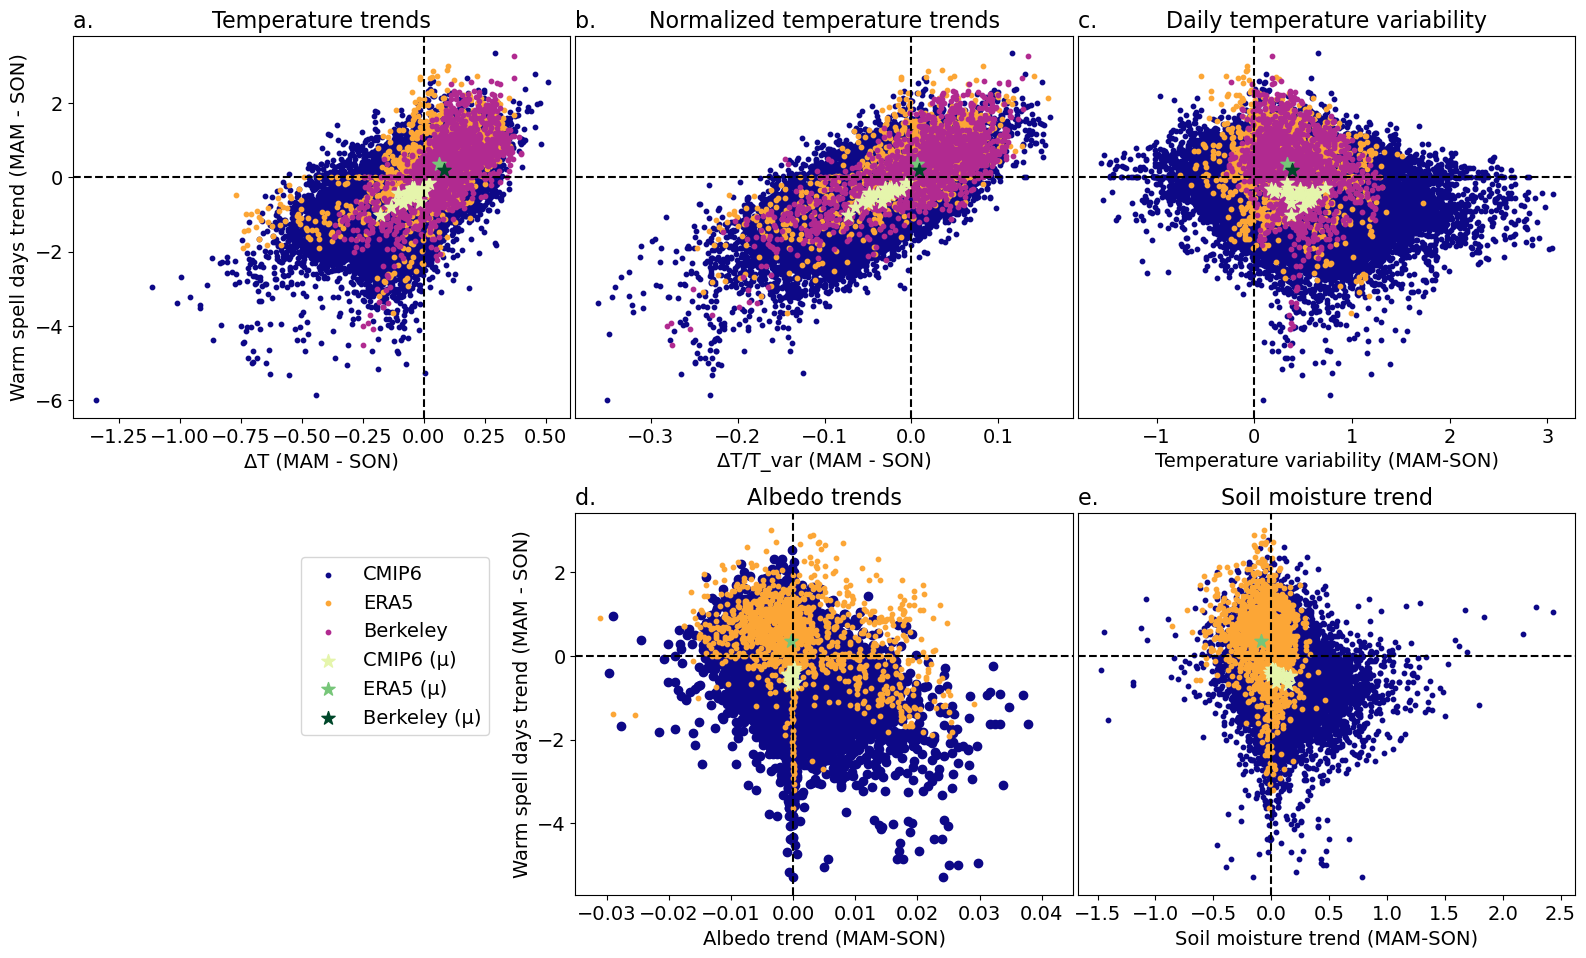

In [34]:
#plot
fig=plt.figure(figsize=(18,10))
#plt.suptitle("Warm spell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')
cmap = plt.get_cmap('plasma')
cmap2 = plt.get_cmap('YlGn')
nums=np.linspace(0,1,18)
# ax=fig.add_subplot(331)
# for i in range(18):
#     ax.scatter(xall.isel(models=i),yall.isel(models=i),c=cmap(nums[i]))
# ax.scatter(xeraall,yeraall,c='k')
# ax.scatter(xbkall,ybkall,c='0.05')

# #plot
# ## plot
fig=plt.figure(figsize=(16,10))
#plt.suptitle("Hotspell trend (MAM - SON) against different parameters (MAM - SON) ",x=0.05, ha='left', fontsize=14,fontweight='bold')

ax1=fig.add_subplot(231)
for i in range(25):
    if i==0:
        ax1.scatter(xtmp_all.isel(models=i),yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
    else:
        ax1.scatter(xtmp_all.isel(models=i),yall.isel(models=i), s=10, alpha=1,c=cmap(0))
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax1.scatter(xtmpera_all,yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
ax1.scatter(xtmpbk_all,ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')

ax1.scatter(xtmp_weighted,y_weighted,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax1.scatter(xtmpera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
ax1.scatter(xtmpbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')


ax1.set_title('Temperature trends', fontsize=16)
ax1.set_ylabel('Warm spell days trend (MAM - SON)', fontsize=14)
ax1.set_xlabel(u'ΔT (MAM - SON)', fontsize=14)
ax1.axhline(color='k', linestyle='--')
ax1.axvline(color='k', linestyle='--')
ax1.set_title(letters[0],loc='left',fontsize=16)

# ax.set_xticks(np.arange(-0.12,0.05,0.04))

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax=fig.add_subplot(232)
for i in range(25):
    ax.scatter(xtmp_var_all.isel(models=i),yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')

ax.scatter(xtmp_varera_all,yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')

ax.scatter(xtmp_varbk_all,ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')


ax.scatter(xtmp_var_weighted,y_weighted,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax.scatter(xtmp_varera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
ax.scatter(xtmp_varbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')


ax.set_title('Normalized temperature trends', fontsize=16)
#ax.set_ylabel('Heatdays trend', fontsize=12)
ax.set_xlabel(u'ΔT/T_var (MAM - SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_yticks([])
ax.set_title(letters[1],loc='left',fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax=fig.add_subplot(233)
for i in range(25):
    ax.scatter(xvar_all.isel(models=i),yall.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')#cmap(nums[i])
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax.scatter(xvarera_all,yera_all,c=cmap(0.8), s=10, alpha=1, label='ERA5')
ax.scatter(xvarbk_all,ybk_all,c=cmap(0.4), s=10, alpha=1, label='Berkeley')


ax.scatter(xvar_weighted,y_weighted,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax.scatter(xvarera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
ax.scatter(xvarbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')

ax.set_title('Daily temperature variability', fontsize=16)
#ax.set_ylabel('Heatdays trend', fontsize=12)
ax.set_yticks([])
ax.set_xlabel('Temperature variability (MAM-SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_title(letters[2],loc='left',fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

ax=fig.add_subplot(235)
for i in range(len(models_albsh)):
    ax.scatter(xalb_all.isel(models=i),yalb_all.isel(models=i),c=cmap(0),label='CMIP6')
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax.scatter(xalbera_all,yera_all, s=10,c=cmap(0.8), label='ERA5')
#ax.scatter(xalbbk_all,ybk_all, s=10,c=cmap(0.4), label='Berkeley')

ax.scatter(xalb_weighted,yalb_weighted,marker='*', s=100,c=cmap2(0.2),label='CMIP6 (μ)')
ax.scatter(xalbera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
#ax.scatter(xalbbk_weighted,ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')


ax.set_title('Albedo trends' , fontsize=16)
#ax.set_ylabel('Heatdays trend', fontsize=12)


ax.set_xlabel('Albedo trend (MAM-SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_title(letters[3],loc='left',fontsize=16)
ax.set_ylabel('Warm spell days trend (MAM - SON)', fontsize=14)

plt.yticks(fontsize=14)
ax.set_xlim([-0.035,0.045])
ax.set_xticks(np.arange(-0.03,0.04,0.01))
plt.xticks(fontsize=14)

ax=fig.add_subplot(236)
for i in range(len(models_smsh)):
    if i==0:
        ax.scatter(xsm_all.isel(models=i),ysm_all.isel(models=i), s=10, alpha=1,c=cmap(0),label='CMIP6')
    else:
        ax.scatter(xsm_all.isel(models=i),ysm_all.isel(models=i), s=10, alpha=1,c=cmap(0))
#ax.vlines(xtmp, ymin=ylow, ymax=yup, color=cmap(0.8),alpha=1, linestyle='--')


ax.scatter(xsm_era_all,yera_all,c=cmap(0.8), s=10,alpha=1, label='ERA5')
#ax.scatter(xsm_bk_all,ybk_all,c=cmap(0.4), s=10,alpha=1, label='Berkeley')



ax.scatter(xsm_weighted,ysm_weighted,marker='*', s=100,c=cmap2(0.2),  label='CMIP6 (μ)')
ax.scatter(xsmera_weighted,yera_weighted,marker='*', s=100,c=cmap2(0.5),label='ERA5 (μ)')
#ax.scatter(xsm_bk_all.mean(dim='z'),ybk_weighted,marker='*', s=100,c=cmap2(0.99),label='Berkeley (μ)')

ax.set_title(letters)
ax.set_title('Soil moisture trend', fontsize=16)
ax.set_yticks([])

ax.set_xlabel('Soil moisture trend (MAM-SON)', fontsize=14)
ax.axhline(color='k', linestyle='--')
ax.axvline(color='k', linestyle='--')
ax.set_title(letters[4],loc='left',fontsize=16)

plt.yticks(fontsize=14)
ax.set_xticks(np.arange(-1.5,3,0.5))
plt.xticks(fontsize=14)

handles=[]
labels=[]
h, l = ax1.get_legend_handles_labels()
handles.extend(h)
labels.extend(l)
fig.legend(handles, labels, loc='lower center', fontsize=14, bbox_to_anchor=(0.25, 0.25))  
plt.tight_layout()  
plt.subplots_adjust(hspace=0.25, wspace=0.01, bottom=0.1)

plt.savefig('plots_fix/constraint_MAM-SON_main_erl.png')
#plt.savefig('plots_sept/constraint_MAM-SON.png')


In [93]:
#correlations across models (temp, temp_var, norm_temp)
from scipy import stats

res = stats.pearsonr(xtmp_weighted,y_weighted)
print('vs tmp: ',res)


# res2 = stats.pearsonr(xtmp_sd, y)
# print('vs sd corrected tmp: ',res2)

res3 = stats.pearsonr(xtmp_var_weighted,y_weighted)
print('vs var corrected tmp: ',res3)

# res = stats.pearsonr(trseas_sd, y)
# print('vs sd: ',res)

res2 = stats.pearsonr(xvar_weighted,y_weighted)
print('vs var: ',res2)




vs tmp:  PearsonRResult(statistic=0.7913109813392503, pvalue=2.476651684522502e-06)
vs var corrected tmp:  PearsonRResult(statistic=0.8574335380934116, pvalue=4.3731651029545716e-08)
vs var:  PearsonRResult(statistic=-0.16697072187051895, pvalue=0.4250236977166622)


In [87]:
#correlations across models (albedo, soil moisture)
from scipy import stats

res = stats.pearsonr(xalb_weighted,yalb_weighted)
print('vs albedo: ',res)


# res2 = stats.pearsonr(xtmp_sd, y)
# print('vs sd corrected tmp: ',res2)

res3 = stats.pearsonr(xsm_weighted,ysm_weighted)
print('vs soil moisture: ',res3)





vs albedo:  PearsonRResult(statistic=0.07990721915481185, pvalue=0.7859730749063616)
vs soil moisture:  PearsonRResult(statistic=-0.5938046839684468, pvalue=0.03237864617902321)


In [88]:
#correlations across models (albedo - low vs. high latitudes)
res1 = stats.pearsonr(xalb_weighted1,yalb_weighted1)
res2=stats.pearsonr(xalb_weighted2,yalb_weighted2)
print('vs albedo (30-60): ',res1)
print('vs albedo (60-80): ',res2)

vs albedo (30-60):  PearsonRResult(statistic=-0.02583976533862982, pvalue=0.9301287262728233)
vs albedo (60-80):  PearsonRResult(statistic=-0.6413595479364413, pvalue=0.013431985068791084)


In [164]:
#correlations across space (temp)
print('ERA5: ',stats.pearsonr(xtmpera_all.dropna(dim='z'), yera_all.dropna(dim='z')))
print('BK: ',stats.pearsonr(xtmpbk_all.dropna(dim='z'), ybk_all.dropna(dim='z')))
sttmp=[]
for i in range(1,25):
    r,p=stats.pearsonr(xtmp_all.isel(models=i).dropna(dim='z'), yall.isel(models=i).dropna(dim='z'))
    print(r,p)
    sttmp.append(r)

ERA5:  PearsonRResult(statistic=0.5651908512940658, pvalue=1.3818141044682534e-124)
BK:  PearsonRResult(statistic=0.6804302137541891, pvalue=5.0200457380685974e-200)
0.5312348693457644 1.2906051301530557e-107
0.3718055191628754 2.61538199455925e-49
0.4885858054101838 7.277619997128668e-89
0.7254273419478788 6.329444459047735e-240
0.5811817385593159 2.7667943929275986e-133
0.56242522802524 3.953499612408914e-123
0.5549812692139305 2.816990533274311e-119
0.2813235021559208 4.336848763108815e-28
0.5739144416335374 2.8483058369920125e-129
0.5683176441731694 2.9992443422786065e-126
0.3985256040998095 4.9782794728175886e-57
0.6833251132826267 2.246590179378692e-202
0.6637944008250495 4.899573562516996e-187
0.7272254049881672 1.100375756304451e-241
0.524004006940613 3.023942769228353e-104
0.6523856154579424 1.3327325905585264e-178
0.33292502503558175 2.6447134950083464e-39
0.729194992536967 1.2519197154839395e-243
0.38063783208086027 8.802585286859214e-52
0.501989225458536 1.7914234565013566e

In [165]:
#correlations across space (norm_temp)
print('ERA5: ',stats.pearsonr(xtmp_varera_all.dropna(dim='z'), yera_all.dropna(dim='z')))
print('BK: ',stats.pearsonr(xtmp_varbk_all.dropna(dim='z'), ybk_all.dropna(dim='z')))
sttmpvar=[]
for i in range(25):
    r,p=stats.pearsonr(xtmp_var_all.isel(models=i).dropna(dim='z'), yall.isel(models=i).dropna(dim='z'))
    print(r,p)
    sttmpvar.append(r)

ERA5:  PearsonRResult(statistic=0.6993624629719092, pvalue=6.684885985329558e-216)
BK:  PearsonRResult(statistic=0.7483659579792454, pvalue=1.7233449513727965e-263)
0.5722970531956594 2.157780983884193e-128
0.6897753129252095 1.0412570553303972e-207
0.4413751248279319 5.529572840111626e-71
0.7703074961652958 1.4716559939790409e-288
0.7979161971807363 0.0
0.6999237140650925 2.164464740741073e-216
0.6829405982723122 4.625178933916106e-202
0.7233896285166526 6.0096324985027556e-238
0.36162329424341155 1.4941788658987323e-46
0.662822977741735 2.6475482146544246e-186
0.6927753019524745 3.080663941107345e-210
0.5392477115619265 1.9049018323872606e-111
0.7007979509717496 3.717158558754035e-217
0.7262052877099202 1.100755619237089e-240
0.7394837931805586 4.5358462700536934e-254
0.6293586432162925 1.2037550958113247e-162
0.7353190865607677 8.748064550912897e-250
0.5501055830747568 8.336364199802525e-117
0.7985319306026447 0.0
0.5945511626465312 6.166695821973919e-141
0.6106482727541165 1.219755

In [167]:
#correlations across space (temp_var)
print('ERA5: ',stats.pearsonr(xvarera_all.dropna(dim='z'), yera_all.dropna(dim='z')))
print('BK: ',stats.pearsonr(xvarbk_all.dropna(dim='z'), ybk_all.dropna(dim='z')))
stvarvar=[]
for i in range(25):
    r,p=stats.pearsonr(xvar_all.isel(models=i).dropna(dim='z'), yall.isel(models=i).dropna(dim='z'))
    print(r,p)
    stvarvar.append(r)

ERA5:  PearsonRResult(statistic=-0.16856121979040592, pvalue=8.184203378061229e-11)
BK:  PearsonRResult(statistic=-0.22524207682297065, pvalue=2.4979439725124585e-18)
-0.09691384951715919 0.00020118084998864156
-0.38270416884831876 2.2643412962730703e-52
-0.2061013098768544 1.548752805229732e-15
-0.414345506641209 6.018196672455658e-62
0.02698375388425452 0.3016864593903021
-0.2877077421692193 2.3447745463813052e-29
-0.46778017486031503 1.2267122159887306e-80
-0.21151382614134806 2.674248446219866e-16
-0.08160100309055758 0.0017600677763729164
-0.11736577181897251 6.574126530451622e-06
-0.16527794137716725 1.904698402063855e-10
-0.29481900610010664 8.311214527699286e-31
-0.052814634534769485 0.043118152477162254
-0.16430825213687195 2.4365485847104046e-10
-0.3490017875708872 2.853552473373506e-43
-0.20758927595596066 9.602321123132905e-16
-0.050641259603493645 0.05247408061110499
-0.29603684739021263 4.646246850556814e-31
-0.2983150545535251 1.5536097326087236e-31
-0.19352121843865672 

In [169]:
#multi-model mean correlations across space (tmp, norm_temp, temp_var)
print(np.array(sttmp).mean())
print(np.array(sttmpvar).mean())
print(np.array(stvarvar).mean())

0.5257634337412197
0.6456842321995596
-0.20083733329322942


In [91]:
#correlations across space (albedo high latitude)
xalbnaeera=xalbera_all2.dropna(dim='z')
yalbnaera=yalbera_all2.where(~np.isnan(xalbnaeera)).dropna(dim='z')
print('ERA5: ',stats.pearsonr(xalbnaeera, yalbnaera))
#print('BK: ',stats.pearsonr(xvarbk_all.dropna(dim='z'), ybk_all.dropna(dim='z')))
stalb=[]
for i in range(len(models_albsh)):
    xalbm=xalb_all2.isel(models=i).dropna(dim='z')
    yalbm=yalb_all2.isel(models=i).where(~np.isnan(xalbm)).dropna(dim='z')
    r,p=stats.pearsonr(xalbm, yalbm)
    print(r,p)
    stalb.append(r)
print('CMIP6 mean:',np.array(stalb).mean())


ERA5:  PearsonRResult(statistic=-0.3814560551112244, pvalue=5.6346779580931666e-21)
-0.5037533332825876 2.13017849393811e-41
-0.19939612952976077 5.237677293632627e-07
-0.20926079361635067 1.3559262226483625e-07
-0.5983793279321576 9.004980314568175e-62
-0.3026645271439934 1.1528799464970495e-14
-0.23930772312297377 1.4554058900746383e-09
-0.3444030852139845 8.655370356285745e-19
-0.5039699017100935 1.944412842771531e-41
-0.4445430223193147 1.4614755586107474e-31
-0.3830280471160414 3.3377951935555157e-23
-0.30841580785038597 3.3973657395220246e-15
-0.24110849886309524 1.086639732270505e-09
-0.21503658643433066 5.957926742401137e-08
-0.5156307098566144 1.29586755771302e-43
CMIP6 mean: -0.35777839242797743


In [91]:
#correlations across space (albedo)
xalbnaeera=xalbera_all.dropna(dim='z')
yalbnaera=yera_all.where(~np.isnan(xalbnaeera)).dropna(dim='z')
print('ERA5: ',stats.pearsonr(xalbnaeera, yalbnaera))
#print('BK: ',stats.pearsonr(xvarbk_all.dropna(dim='z'), ybk_all.dropna(dim='z')))
stalb=[]
for i in range(len(models_albsh)):
    xalbm=xalb_all.isel(models=i).dropna(dim='z')
    yalbm=yalb_all.isel(models=i).where(~np.isnan(xalbm)).dropna(dim='z')
    r,p=stats.pearsonr(xalbm, yalbm)
    print(r,p)
    stalb.append(r)
print('CMIP6 mean:',np.array(stalb).mean())


ERA5:  PearsonRResult(statistic=-0.27994015737351685, pvalue=9.155968141179226e-27)
-0.2897944346638166 8.8875753438913e-30
-0.15106767214556194 6.078764385716915e-09
-0.06299377598696726 0.015817815555374874
-0.42604185960668356 9.328710834482074e-66
-0.35552421019365515 6.00450083929525e-45
-0.2896609992499433 9.458693670747126e-30
-0.23821116166762485 2.2551354478637868e-20
-0.2496101957570053 2.8338412601030433e-22
-0.4761235676491988 7.20696488604127e-84
-0.3198175512410499 3.0622221337903403e-36
-0.41018083955069784 1.258622436844968e-60
-0.19267208318537804 9.829636698025879e-14
-0.15007649254714084 7.650347265918153e-09
-0.47742044049669147 2.225621204269899e-84
CMIP6 mean: -0.2920853774243867


In [92]:
#correlations across space (soil moisture)
xsmnaeera=xsm_era_all.dropna(dim='z')
ysmnaera=yera_all.where(~np.isnan(xsmnaeera)).dropna(dim='z')
print('ERA5: ',stats.pearsonr(xsmnaeera, ysmnaera))
#print('BK: ',stats.pearsonr(xvarbk_all.dropna(dim='z'), ybk_all.dropna(dim='z')))
stsm=[]
for i in range(len(models_smsh)):
    xsmm=xsm_all.isel(models=i).dropna(dim='z')
    ysmm=ysm_all.isel(models=i).where(~np.isnan(xsmm)).dropna(dim='z')
    r,p=stats.pearsonr(xsmm, ysmm)
    print(r,p)
    stsm.append(r)
print('CMIP6 mean:',np.array(stsm).mean())

ERA5:  PearsonRResult(statistic=-0.17814542361722233, pvalue=6.310779415079067e-12)
0.03858758149092513 0.13960860119740312
-0.4132333652105676 4.404099587701319e-60
0.08088230899650886 0.002206481649807161
-0.16725361191417368 1.96438464401898e-10
-0.16844009953910877 1.4561517075936822e-10
-0.17895047868311836 5.055167571454346e-12
-0.1113645563315045 1.9105963826593455e-05
-0.23930073777502722 1.4987065698603074e-20
-0.019596343584923254 0.4532545115194903
-0.1246024075726316 1.6925102246537552e-06
-0.2536832555990753 5.613948115437174e-23
-0.10050017192962513 0.00011535873389262862
-0.021821853361916648 0.40360774767591406
CMIP6 mean: -0.1291751531549414


# Future trend plots

In [55]:
#read trend
trseas_heatfut=xr.open_dataset('cmip6_heat_fut_mktrends.nc').tas
pvseas_heatfut=xr.open_dataset('cmip6_heat_fut_mkpvals.nc').tas

In [56]:
#sum for seasonal
count_days=[90,92,92,91]


cmipfut_seas=trseas_heatfut.copy()
for i in range(4):
    cmipfut_seas[i,]=count_days[i]*trseas_heatfut[i,]

In [53]:
#temp trends
trseas_tmpfut=xr.open_dataset('cmip6_tmean_trend_final_2030-2099.nc').tas
pvseas_tmpfut=xr.open_dataset('cmip6_tmean_trendpvals_final_2030-2099.nc').tas

trseas_tmp=xr.open_dataset('cmip6_tas_day_hist_mktrends.nc').tas
pvseas_tmp=xr.open_dataset('cmip6_tas_day_hist_mkpvals.nc').tas

In [54]:
#zonal deviations historical corrected
hist_trendnorm=trseas_heat/trseas_tmp.mean()

clim_annual_mn2=hist_trendnorm.mean(dim='season')


clim_dif_hist=hist_trendnorm.mean(dim='longitude')/clim_annual_mn2.mean(dim='longitude')
clim_dif_hist_mean_cor=clim_dif_hist.mean(dim='models')
clim_dif_hist_upper_cor=clim_dif_hist.quantile(0.975,dim='models')
clim_dif_hist_lower_cor=clim_dif_hist.quantile(0.025,dim='models')

In [57]:
#zonal deviations future corrected
fut_trendnorm=trseas_heatfut/trseas_tmpfut.mean()

clim_annual_mnfut=fut_trendnorm.mean(dim='season')


clim_dif_fut=fut_trendnorm.mean(dim='longitude')/clim_annual_mnfut.mean(dim='longitude')
clim_dif_fut_mean_cor=clim_dif_fut.mean(dim='models')
clim_dif_fut_upper_cor=clim_dif_fut.quantile(0.975,dim='models')
clim_dif_fut_lower_cor=clim_dif_fut.quantile(0.025,dim='models')

In [61]:
#zonal ratios (historical and future) corrected


trseas_heat=10*cmiptr_seas.copy(deep=True)


trend_annual_mn2=trseas_heat.mean(dim='season')

trend_ann_cmip=trend_annual_mn2.mean(dim='longitude')
trend_dif_cmip=((trseas_heat-trend_annual_mn2).mean(dim='longitude'))
trend_dif_cmip_mean=trend_dif_cmip.mean(dim='models')
trend_dif_cmip_upper=trend_dif_cmip.quantile(0.975,dim='models')
trend_dif_cmip_lower=trend_dif_cmip.quantile(0.025,dim='models')

#lat vatiations
trseasfut_heat=10*cmipfut_seas.copy(deep=True)
trend_annual_mnfut2=trseasfut_heat.mean(dim='season')

trend_dif_cmipfut=((trseasfut_heat-trend_annual_mnfut2).mean(dim='longitude'))
trend_dif_cmipfut_mean=trend_dif_cmipfut.mean(dim='models')
trend_dif_cmipfut_upper=trend_dif_cmipfut.quantile(0.975,dim='models')
trend_dif_cmipfut_lower=trend_dif_cmipfut.quantile(0.025,dim='models')


In [ ]:
#plot
import matplotlib.ticker as mticker
titles=trseas_tmpfut.season.values
#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(16,7))
numplots=np.arange(1,5)
#gs = fig.add_gridspec(5,4)
order=np.array([0,2,1,3])

for i in range (4):
    if i ==0:
        ax=fig.add_axes([0.2,0.75,0.37,0.3],projection=ccrs.PlateCarree())
    elif i ==1:
        ax=fig.add_axes([0.2,0.58,0.37,0.3],projection=ccrs.PlateCarree())
    elif i ==2:
        ax=fig.add_axes([0.2,0.41,0.37,0.3],projection=ccrs.PlateCarree())
    else:
        ax=fig.add_axes([0.2,0.24,0.37,0.3],projection=ccrs.PlateCarree())

    pvs=xr.where(cmipfut_seas.isel(season=order[i])>0,1,0) 
    pval=xr.where(pvs.mean(dim='models')>0.8,cmipfut_seas.isel(season=order[i]),np.nan) 
    m=(10*pval.mean(dim='models')).plot(ax=ax, vmax=12,vmin=0,cmap='Reds',transform=ccrs.PlateCarree(),add_colorbar=False)
#         else:
#             dats[i].plot(ax=ax,transform=ccrs.PlateCarree(),cbar_kwargs={'orientation':'horizontal'})

    ax.set_ylabel(titles[i])
    ax.yaxis.set_label_coords(0.1,0.75)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.ylocator = mticker.FixedLocator([ 30, 50, 70])
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    ax.coastlines()
    if i==0:
        ax.set_title('CMIP6 2030-2099 warm spell trends',fontsize=16, y=0.97)
    else:
        ax.set_title('')
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.97)
    ax.text(-0.12, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
#
#     if titles.any():
#         ax.set_title('CMIP6 Future '+titles[i])
    if i<3:
        gl.bottom_labels = False
        

   
    if i ==0:
        ax=fig.add_axes([0.6,0.84,0.14,0.125])
    elif i ==1:
        ax=fig.add_axes([0.6,0.67,0.14,0.125])
    elif i ==2:
        ax=fig.add_axes([0.6,0.5,0.14,0.125])
    else:
        ax=fig.add_axes([0.6,0.33,0.14,0.125])

        #ax.set_yticks([])
    #ax.set_title(letters[3*i+1],loc='left',fontsize=12, y=0.97)
        
    lat=trend_dif_cmip_mean.latitude
    ax.plot(trend_dif_cmipfut_mean.isel(season=order[i]),lat,  color='blue', label='Future')
#     ax.plot(trend_dif_cmipfut_upper.isel(season=order[i]),lat,linestyle='--', color='0.8')
#     ax.plot(trend_dif_cmipfut_lower.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,trend_dif_cmipfut_lower.isel(season=order[i]), trend_dif_cmipfut_upper.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(0,color='k')
    ax.plot(trend_dif_cmip_mean.isel(season=order[i]),lat, color='blue',linestyle='--', label='Historical')

    ax.set_xlim([-6,6])
    ax.set_ylabel('')
    ax.set_yticks([30,50,70])
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
    if i==0 or i==2:
        ax.set_xticks([])
    
#     if i==3:
#         plt.legend()
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.97)
    
    if i==0:
        ax.set_title('Seasonal',fontsize=16, y=0.97)
    if i<3:
        ax.set_xticks([])

    else:
        ax.set_xticks(np.arange(-2.5,7.5,2.5))
        ax.set_xticklabels(['-2.5','0','2.5','5'])
        ax.set_xlabel('minus annual mean', fontsize=14)
        #ax.set_xlabel('hot spell trend per decade', fontsize=12)
    
    if i==0:
        ax=fig.add_axes([0.75,0.84,0.14,0.125])
    elif i==1:
        ax=fig.add_axes([0.75,0.67,0.14,0.125])

    elif i==2:
        ax=fig.add_axes([0.75,0.5,0.14,0.125])
        #ax.set_yticks([])
    else:
        ax=fig.add_axes([0.75,0.33,0.14,0.125])
        
    lat=trend_dif_cmip_mean.latitude
    ax.plot(clim_dif_fut_mean_cor.isel(season=order[i]),lat,  color='blue', label='Future')
#     ax.plot(clim_dif_fut_upper_cor.isel(season=order[i]),lat,linestyle='--', color='0.8')
#     ax.plot(clim_dif_fut_lower_cor.isel(season=order[i]),lat,linestyle='--', color='0.8')
    ax.fill_betweenx(lat,clim_dif_fut_lower_cor.isel(season=order[i]), clim_dif_fut_upper_cor.isel(season=order[i]), color='lightblue', alpha=0.5)
    ax.axvline(1,color='k')
    ax.plot(clim_dif_hist_mean_cor.isel(season=order[i]),lat, color='blue',linestyle='--', label='Historical')

    ax.set_xlim([0,2])
    ax.set_ylabel('')
    ax.set_yticks([])
    
#     if i==0 or i==2:
#         ax.set_xticks([])
    
#     if i==3:
#         plt.legend()
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.97)
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
    if i==0:
        ax.set_title('Normalized',fontsize=16, y=0.97)
    if i<3:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(0,2.5,0.5))
        #ax.set_xticklabels(['-0.04','0','0.04','0.08'])
        #ax.set_xticklabels(np.arange(-0.8,1.2,0.4))
        #ax.set_xlabel('hot spell cmip per degree warming', fontsize=12)
      
    if i==3:
        plt.legend(title='warm spell days trend per season per decade', title_fontsize=14,loc='lower left',ncol=3, bbox_to_anchor=(-1, -1.45), fontsize=13)
        ax.set_xlabel('ratio to annual mean', fontsize=14)
    
cbar_ax = fig.add_axes([0.25, 0.25, 0.28, 0.02])
cbl=fig.colorbar(m, cax=cbar_ax, extend='max',orientation='horizontal')
cbl.set_label(label="warm spell days trend per season per decade",size=14)
# cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.15, bottom=0.28)

# plt.tight_layout()
plt.savefig('plots_fix/Future_trends_main_erl.png')
plt.show()

## Sensitivity of time period

In [3]:
#cmip
trseas_mn=xr.open_dataset('cmip6/heat/cmip6_hot_trend_25mods_1980-2021_fixednew.nc').htdays
pvseas_mn=xr.open_dataset('cmip6/heat/cmip6_hot_trendpvals_25mods_1980-2021_fixednew.nc').htdays

In [4]:
#era5 trend
trseas_mn_era=xr.open_dataset('era5/era5_hot_trend_final_1980-2021_fixednew.nc').htdays
pvseas_mn_era=xr.open_dataset('era5/era5_hot_trendpvals_final_1980-2021_fixednew.nc').htdays

In [6]:
#berkley trend
trseas_mn_bk= xr.open_dataset('berkeley/berkeley_hot_trend_final_1980-2021_fixednew.nc').htdays
pvseas_mn_bk= xr.open_dataset('berkeley/berkeley_hot_trendpvals_final_1980-2021_fixednew.nc').htdays

In [31]:
#trseas_mn_bk2= xr.open_dataset('berkeley/berkeley_hot_trend_final_1950-2021.nc').htdays

In [7]:
#hatching for CMIP CI
trseas_heat=landmask(trseas_mn).copy(deep=True)
trseasera_heat=landmask(trseas_mn_era).copy(deep=True)
trseasbk_heat=landmask(trseas_mn_bk).copy(deep=True)

cmip_seastr_upper1=trseas_heat.quantile(0.975,dim=['models'])
cmip_seastr_lower1=trseas_heat.quantile(0.025,dim=['models'])

era_hatch_tr=xr.where((trseasera_heat>cmip_seastr_upper1)|(trseasera_heat<cmip_seastr_lower1), 1,np.nan)
bk_hatch_tr=xr.where((trseasbk_heat>cmip_seastr_upper1)|(trseasbk_heat<cmip_seastr_lower1), 1,np.nan)



/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [81]:
#1950-2021cmip
trseas_mn=xr.open_dataset('cmip6/heat/cmip6_hot_trend_25mods_1950-2021_fixednew.nc').htdays
pvseas_mn=xr.open_dataset('cmip6/heat/cmip6_hot_trendpvals_25mods_1950-2021_fixednew.nc').htdays

#era5 trend
trseas_mn_era=xr.open_dataset('era5/era5_hot_trend_final_1950-2021_fixednew.nc').htdays
pvseas_mn_era=xr.open_dataset('era5/era5_hot_trendpvals_final_1950-2021_fixednew.nc').htdays

#berkley trend
trseas_mn_bk= xr.open_dataset('berkeley/berkeley_hot_trend_final_1950-2021_fixednew.nc').htdays
pvseas_mn_bk= xr.open_dataset('berkeley/berkeley_hot_trendpvals_final_1950-2021_fixednew.nc').htdays

trseas_heat=landmask(trseas_mn).copy(deep=True)
trseasera_heat=landmask(trseas_mn_era).copy(deep=True)
trseasbk_heat=landmask(trseas_mn_bk).copy(deep=True)

In [82]:
#hatch
cmip_seastr_upper1=trseas_heat.quantile(0.975,dim=['models'])
cmip_seastr_lower1=trseas_heat.quantile(0.025,dim=['models'])

era_hatch_tr=xr.where((trseasera_heat>cmip_seastr_upper1)|(trseasera_heat<cmip_seastr_lower1), 1,np.nan)
bk_hatch_tr=xr.where((trseasbk_heat>cmip_seastr_upper1)|(trseasbk_heat<cmip_seastr_lower1), 1,np.nan)

/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [83]:
#1960-2021
trseas_mn60=xr.open_dataset('cmip6/heat/cmip6_hot_trend_25mods_1960-2021_fixednew.nc').htdays
pvseas_mn60=xr.open_dataset('cmip6/heat/cmip6_hot_trendpvals_25mods_1960-2021_fixednew.nc').htdays
#era5 trend
trseas_mn_era60=xr.open_dataset('era5/era5_hot_trend_final_1960-2021_fixednew.nc').htdays
pvseas_mn_era60=xr.open_dataset('era5/era5_hot_trendpvals_final_1960-2021_fixednew.nc').htdays

trseas_mn_bk60= xr.open_dataset('berkeley/berkeley_hot_trend_final_1960-2021_fixednew.nc').htdays
pvseas_mn_bk60= xr.open_dataset('berkeley/berkeley_hot_trendpvals_final_1960-2021_fixednew.nc').htdays

trseas_heat60=landmask(trseas_mn60).copy(deep=True)
trseasera_heat60=landmask(trseas_mn_era60).copy(deep=True)
trseasbk_heat60=landmask(trseas_mn_bk60).copy(deep=True)

In [84]:
#hatch
cmip_seastr_upper1=trseas_heat60.quantile(0.975,dim=['models'])
cmip_seastr_lower1=trseas_heat60.quantile(0.025,dim=['models'])

era_hatch_tr60=xr.where((trseasera_heat60>cmip_seastr_upper1)|(trseasera_heat60<cmip_seastr_lower1), 1,np.nan)
bk_hatch_tr60=xr.where((trseasbk_heat60>cmip_seastr_upper1)|(trseasbk_heat60<cmip_seastr_lower1), 1,np.nan)

/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [85]:
#1980-2021
trseas_mn80=xr.open_dataset('cmip6/heat/cmip6_hot_trend_25mods_1980-2021_fixednew.nc').htdays
pvseas_mn80=xr.open_dataset('cmip6/heat/cmip6_hot_trendpvals_25mods_1980-2021_fixednew.nc').htdays
#era5 trend
trseas_mn_era80=xr.open_dataset('era5/era5_hot_trend_final_1980-2021_fixednew.nc').htdays
pvseas_mn_era80=xr.open_dataset('era5/era5_hot_trendpvals_final_1980-2021_fixednew.nc').htdays

trseas_mn_bk80= xr.open_dataset('berkeley/berkeley_hot_trend_final_1980-2021_fixednew.nc').htdays
pvseas_mn_bk80= xr.open_dataset('berkeley/berkeley_hot_trendpvals_final_1980-2021_fixednew.nc').htdays

trseas_heat80=landmask(trseas_mn80).copy(deep=True)
trseasera_heat80=landmask(trseas_mn_era80).copy(deep=True)
trseasbk_heat80=landmask(trseas_mn_bk80).copy(deep=True)

In [86]:
#hatch
cmip_seastr_upper1=trseas_heat80.quantile(0.975,dim=['models'])
cmip_seastr_lower1=trseas_heat80.quantile(0.025,dim=['models'])

era_hatch_tr80=xr.where((trseasera_heat80>cmip_seastr_upper1)|(trseasera_heat80<cmip_seastr_lower1), 1,np.nan)
bk_hatch_tr80=xr.where((trseasbk_heat80>cmip_seastr_upper1)|(trseasbk_heat80<cmip_seastr_lower1), 1,np.nan)

/home/rwhite/ladmasu/mambaforge/envs/comput/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


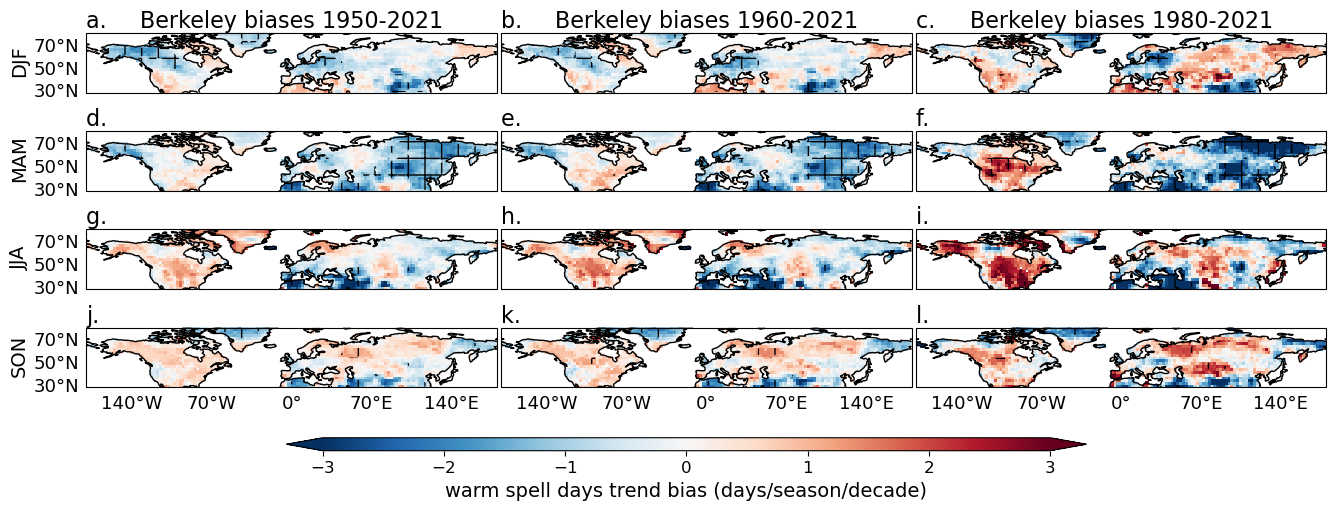

In [88]:
#Plot biases against berkeley
titles=pvseas_mn_bk.season.values
#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(16,6.5))
numplots=np.arange(1,5)
gs = fig.add_gridspec(5,3)

order=np.array([0,2,1,3])
for i in range (4):
    ax=fig.add_subplot(4,3,3*i+1,projection =ccrs.PlateCarree())
    difs=10*trseas_heat.isel(season=order[i]).mean(dim='models') - 10*trseasbk_heat.isel(season=order[i])

    m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(bk_hatch_tr.longitude,bk_hatch_tr.latitude, bk_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    
    #gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    ax.text(-0.14, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('Berkeley biases 1950-2021', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
    ax=fig.add_subplot(4,3,3*i+2,projection =ccrs.PlateCarree())
    difs=10*trseas_heat60.isel(season=order[i]).mean(dim='models') - 10*trseasbk_heat60.isel(season=order[i])

    m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(bk_hatch_tr60.longitude,bk_hatch_tr60.latitude, bk_hatch_tr60.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('Berkeley biases 1960-2021', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    
    ax=fig.add_subplot(4,3,3*i+3,projection =ccrs.PlateCarree())
    difs=10*trseas_heat80.isel(season=order[i]).mean(dim='models') - 10*trseasbk_heat80.isel(season=order[i])

    m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(bk_hatch_tr80.longitude,bk_hatch_tr80.latitude, bk_hatch_tr80.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('Berkeley biases 1980-2021', fontsize=16,y=0.96)
    else:
        ax.set_title('')
        
#     ax=fig.add_subplot(4,4,4*i+4,projection =ccrs.PlateCarree())
#     difs=10*trseas_heat10.isel(season=order[i]).mean(dim='models') - 10*trseasbk_heat10.isel(season=order[i])

#     m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
#     ax.contourf(bk_hatch_tr10.longitude,bk_hatch_tr10.latitude, bk_hatch_tr10.isel(season=order[i]),hatches='++++' ,alpha=0)
   
#     gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
#     gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
#     gl.top_labels = False
#     gl.right_labels = False

#     gl.left_labels = False
    
# #     gl.ylabels_rit2mt = False
#     gl.xlabel_style = {'size': 13}
#     gl.ylabel_style = {'size': 13}
#     ax.coastlines()
    
#     ax.set_title(letters[4*i+3],loc='left',fontsize=16, y=0.96)
#     if i<3:
#         gl.bottom_labels = False
#     if i==0:
#         ax.set_title('Berkeley biases 1950-2010', fontsize=16,y=0.96)
#     else:
#         ax.set_title('')
    
    
cbar_ax = fig.add_axes([0.25, 0.21, 0.5, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="warm spell days trend bias (days/season/decade)",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.03, wspace=0.01, bottom=0.28)

plt.savefig('plots_fix/berkeley_sensitivity_supporting.png')

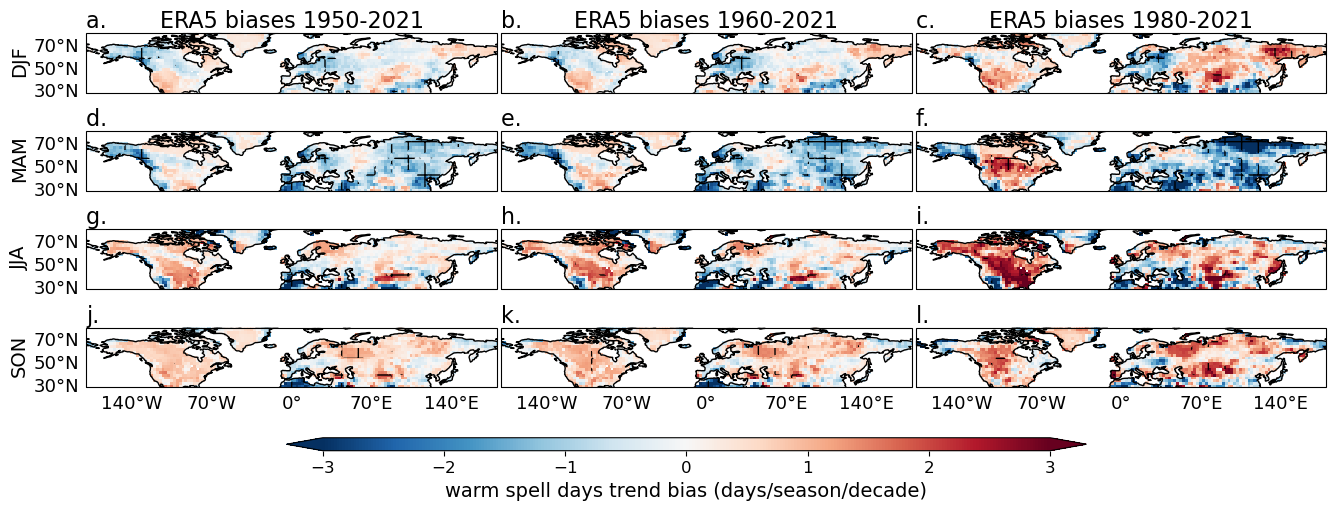

In [87]:
#Plot biases against era5
titles=pvseas_mn_era.season.values
#map_plotter(dats,2,2,4,titles,cmap='Reds',vmax=0.05,height=5)

fig=plt.figure(figsize=(16,6.5))
numplots=np.arange(1,5)
gs = fig.add_gridspec(5,3)

order=np.array([0,2,1,3])
for i in range (4):
    ax=fig.add_subplot(4,3,3*i+1,projection =ccrs.PlateCarree())
    difs=10*trseas_heat.isel(season=order[i]).mean(dim='models') - 10*trseasera_heat.isel(season=order[i])

    m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(era_hatch_tr.longitude,era_hatch_tr.latitude, era_hatch_tr.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False
    
    #gl.left_labels = False
    
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    ax.text(-0.14, 0.55, titles[order[i]], va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax.transAxes, fontsize=14)
 
    ax.set_title(letters[3*i],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('ERA5 biases 1950-2021', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    if i<3:
        gl.bottom_labels = False
    ax=fig.add_subplot(4,3,3*i+2,projection =ccrs.PlateCarree())
    difs=10*trseas_heat60.isel(season=order[i]).mean(dim='models') - 10*trseasera_heat60.isel(season=order[i])

    m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(era_hatch_tr60.longitude,era_hatch_tr60.latitude, era_hatch_tr60.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    ax.set_title(letters[3*i+1],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('ERA5 biases 1960-2021', fontsize=16,y=0.96)
    else:
        ax.set_title('')
    
    ax=fig.add_subplot(4,3,3*i+3,projection =ccrs.PlateCarree())
    difs=10*trseas_heat80.isel(season=order[i]).mean(dim='models') - 10*trseasera_heat80.isel(season=order[i])

    m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
    ax.contourf(era_hatch_tr80.longitude,era_hatch_tr80.latitude, era_hatch_tr80.isel(season=order[i]),hatches='++++' ,alpha=0)
   
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
    gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
    gl.top_labels = False
    gl.right_labels = False

    gl.left_labels = False
    if i<3:
        gl.bottom_labels = False
#     gl.ylabels_rit2mt = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    ax.coastlines()
    
    ax.set_title(letters[3*i+2],loc='left',fontsize=16, y=0.96)
    
    if i==0:
        ax.set_title('ERA5 biases 1980-2021', fontsize=16,y=0.96)
    else:
        ax.set_title('')
        
#     ax=fig.add_subplot(4,4,4*i+4,projection =ccrs.PlateCarree())
#     difs=10*trseas_heat10.isel(season=order[i]).mean(dim='models') - 10*trseasera_heat10.isel(season=order[i])

#     m2=(difs).plot(ax=ax, cmap='RdBu_r', vmin=-3,vmax=3,transform=ccrs.PlateCarree(),add_colorbar=False)
#     ax.contourf(era_hatch_tr10.longitude,era_hatch_tr10.latitude, era_hatch_tr10.isel(season=order[i]),hatches='++++' ,alpha=0)
   
#     gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True, dms=True, x_inline=False, y_inline=False,color = "None")
#     gl.xlocator = mticker.FixedLocator([ -140, -70, 0, 70, 140])
#     gl.top_labels = False
#     gl.right_labels = False

#     gl.left_labels = False
    
# #     gl.ylabels_rit2mt = False
#     gl.xlabel_style = {'size': 13}
#     gl.ylabel_style = {'size': 13}
#     ax.coastlines()
    
#     ax.set_title(letters[4*i+3],loc='left',fontsize=16, y=0.96)
#     if i<3:
#         gl.bottom_labels = False
#     if i==0:
#         ax.set_title('ERA5 biases 1950-2010', fontsize=16,y=0.96)
#     else:
#         ax.set_title('')
    
    
cbar_ax = fig.add_axes([0.25, 0.21, 0.5, 0.02])
cbl=fig.colorbar(m2, cax=cbar_ax, extend='both',orientation='horizontal')
cbl.set_label(label="warm spell days trend bias (days/season/decade)",size=14)
cbl.ax.tick_params(labelsize=12)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.03, wspace=0.01, bottom=0.28)

plt.savefig('plots_fix/era_sensitivity_supporting.png')